# 1. Środowisko eksperymentalne

Niniejszy notebook implementuje eksperyment badawczy, dotyczący detekcji anomalii w ruchu sieciowym z wykorzystaniem zbioru danych CIC-IDS-2017 oraz algorytmów nienadzorowanego uczenia maszynowego.

### Import Bibliotek

Na początku importujemy wszystkie niezbędne biblioteki. Będziemy korzystać z `pandas` do manipulacji danymi, `numpy` do operacji numerycznych, `scikit-learn` do modeli uczenia maszynowego, preprocessingu i metryk, `tensorflow/keras` do budowy autoenkodera oraz `matplotlib` i `seaborn` do wizualizacji. 

In [2]:
import sklearn
print(sklearn.__version__)

1.8.0


In [3]:
# from thundersvm import OneClassSVM
from sklearn.svm import OneClassSVM

In [4]:
import pandas as pd
import numpy as np
import glob
import os
import time
import pickle
import shap
import tqdm as notebook_tqdm

# Trening i modele
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, QuantileTransformer
from sklearn.base import BaseEstimator, clone
from sklearn.decomposition import PCA
from itertools import product
import random

# Dla Autoenkodera (TensorFlow/Keras)
# import tensorflow as tf
# from tensorflow.keras.models import Model, Sequential
# from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping

# Metryki
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Testy statystyczne
from scipy.stats import shapiro, levene, friedmanchisquare
import scikit_posthocs as sp

# Wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia dla czytelności
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Ustawienie ziarna losowości dla powtarzalności
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# tf.random.set_seed(RANDOM_STATE)

# print(f"TensorFlow version: {tf.__version__}")

/home/zuza/zuza/PWN/PNW2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
print(type(OneClassSVM()))

<class 'sklearn.svm._classes.OneClassSVM'>


In [13]:
os.getcwd()

'/home/zuza/zuza/PWN/PNW2/analytic_pipline'

## 1.1 Preprocessing danych

W tej sekcji zajmiemy się przygotowaniem danych CIC-IDS-2017 do treningu modeli.

### 1. Wczytanie i połączenie danych

Pliki CSV składające się na zbiór CIC-IDS-2017 zostaną wczytane i połączone w jeden spójny zbiór danych.

In [16]:
DATA_PATH = './MachineLearningCVE/'

all_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
df_list = []
for filename in all_files:
    df_file = pd.read_csv(filename, low_memory=False)
    df_list.append(df_file)
    print(f"Wczytano: {filename}, kształt: {df_file.shape}")

df_raw = pd.concat(df_list, ignore_index=True)
print(f"\nPołączony zbiór danych ma kształt: {df_raw.shape}")
print(df_raw.head())

Wczytano: ./MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv, kształt: (529918, 79)
Wczytano: ./MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv, kształt: (191033, 79)
Wczytano: ./MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv, kształt: (286467, 79)
Wczytano: ./MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv, kształt: (225745, 79)
Wczytano: ./MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv, kształt: (170366, 79)
Wczytano: ./MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv, kształt: (445909, 79)
Wczytano: ./MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv, kształt: (288602, 79)
Wczytano: ./MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv, kształt: (692703, 79)

Połączony zbiór danych ma kształt: (2830743, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              49188               4                   2   
1              49188             

Wczytaj gotowe, połaczne dane 

In [4]:
df_cleaned = pd.read_csv('./MachineLearningCVE/cleaned_dataset.csv', low_memory=False)

In [11]:
display(df_cleaned)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,binary_label
0,49188,4,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,3.000000e+06,5.000000e+05,4.0,0.000000,4,4,4,4.000,0.00000,4,4,0,0.00000,0.00000,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,49188,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.0,0.000000,1,1,1,1.000,0.00000,1,1,0,0.00000,0.00000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,49486,3,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,4.000000e+06,6.666667e+05,3.0,0.000000,3,3,3,3.000,0.00000,3,3,0,0.00000,0.00000,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,49486,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.0,0.000000,1,1,1,1.000,0.00000,1,1,0,0.00000,0.00000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,88,609,7,4,484,414,233,0,69.14286,111.967896,207,0,103.5,119.511505,1.474548e+06,1.806240e+04,60.9,115.194954,381,2,609,101.500,177.08952,460,2,467,155.66667,263.56088,460,3,0,0,164,104,1.149425e+04,6568.144500,0,233,74.833336,107.527440,11562.15100,0,0,0,1,0,0,0,0,0,81.636360,69.14286,103.5,164,7,484,4,414,8192,2053,5,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520793,53,32215,4,2,112,152,28,28,28.00000,0.000000,76,76,76.0,0.000000,8.194940e+03,1.862486e+02,6443.0,13617.579000,30780,3,30832,10277.333,17755.84400,30780,4,3,3.00000,0.00000,3,3,0,0,80,64,1.241658e+02,62.082882,28,76,41.714287,23.421602,548.57140,0,0,0,0,0,0,0,0,0,48.666668,28.00000,76.0,80,4,112,2,152,-1,-1,3,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2520794,53,324,2,2,84,362,42,42,42.00000,0.000000,181,181,181.0,0.000000,1.376543e+06,1.234568e+04,108.0,183.597380,320,2,2,2.000,0.00000,2,2,2,2.00000,0.00000,2,2,0,0,40,40,6.172839e+03,6172.839400,42,181,97.600000,76.133440,5796.30000,0,0,0,0,0,0,0,0,1,122.000000,42.00000,181.0,40,2,84,2,362,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2520795,58030,82,2,1,31,6,31,0,15.50000,21.920311,6,6,6.0,0.000000,4.512195e+05,3.658537e+04,41.0,52.325900,78,4,4,4.000,0.00000,4,4,0,0.00000,0.00000,0,0,1,0,64,20,2.439024e+04,12195.122000,0,31,17.000000,16.350330,267.33334,0,1,0,0,1,0,0,0,0,22.666666,15.50000,6.0,64,2,31,1,6,

### wersja z jedną .csv - DO MNIEJSZYCH TESTÓW !!!

In [ ]:
filename = './MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv'

df_raw = pd.read_csv(filename, low_memory=False)
print(f"Wczytano: {filename}, kształt: {df_raw.shape}")
df_raw.head()

In [6]:
print("Czy spacje są na początku nazw kolumn?", df_raw.columns.str.startswith(' ').any())
print("Czy spacje są na końcu nazw kolumn?", df_raw.columns.str.endswith(' ').any())
df_raw.columns = df_raw.columns.str.strip()
print("Nazwy kolumn po usunięciu spacji:", df_raw.columns.tolist())

Czy spacje są na początku nazw kolumn? True
Czy spacje są na końcu nazw kolumn? False
Nazwy kolumn po usunięciu spacji: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SY

### 2. Czyszczenie danych

Proces czyszczenia obejmuje:
- Usunięcie wierszy zawierających brakujące wartości (NaN) lub wartości nieskończone (Infinity).
- Usunięcie zduplikowanych rekordów.

In [19]:
label_column_name = ' Label'
df_cleaned = df_raw.copy()

# Sprawdźmy czy występują wartości nieskończone (inf)
count = df_cleaned[df_cleaned == np.inf].count()
for col in df_cleaned.columns:
    if count[col] > 0:
        print(f"Kolumna {col} zawiera {count[col]} nieskończoności (inf)")

Kolumna Flow Bytes/s zawiera 1509 nieskończoności (inf)
Kolumna  Flow Packets/s zawiera 2867 nieskończoności (inf)


In [20]:
print("Kształt przed czyszczeniem:", df_cleaned.shape)

# Usuwanie wierszy z NaN lub Inf
df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)
before_drop = df_cleaned.shape[0]
df_cleaned.dropna(inplace=True)
print(f"Liczba usuniętych wierszy: {before_drop - df_cleaned.shape[0]}")
print(f"Liczba wierszy po usunięciu NaN: {df_cleaned.shape[0]}")

# Usuwanie zduplikowanych rekordów
before_drop = df_cleaned.shape[0]
df_cleaned.drop_duplicates(inplace=True)
print(f"Liczba usuniętych duplikatów: {before_drop - df_cleaned.shape[0]}")

print(f"Kształt po czyszczeniu: {df_cleaned.shape}")

Kształt przed czyszczeniem: (2830743, 79)
Liczba usuniętych wierszy: 2867
Liczba wierszy po usunięciu NaN: 2827876
Liczba usuniętych duplikatów: 307078
Kształt po czyszczeniu: (2520798, 79)


In [21]:
# Sprawdzenie unikalnych wartości w kolumnach
num_unique = df_cleaned.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
df_cleaned = df_cleaned[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index([' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk',
       ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [22]:
df_cleaned[' Label']

0          BENIGN
1          BENIGN
4          BENIGN
5          BENIGN
8          BENIGN
            ...  
2830738    BENIGN
2830739    BENIGN
2830740    BENIGN
2830741    BENIGN
2830742    BENIGN
Name:  Label, Length: 2520798, dtype: object

In [23]:
display(df_cleaned.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
       ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance',
       'FIN Flag Count', ' SYN Flag Count', 

### 3. Etykietowanie binarne

Oryginalne, wieloklasowe etykiety zostaną przekształcone do postaci binarnej:
- Klasa 0: dla ruchu normalnego (oryginalnie oznaczonego jako ’BENIGN’).
- Klasa 1: dla wszystkich typów ataków (anomalie).

In [ ]:
print(f"Oryginalne etykiety, kolumna '{label_column_name}':")
unique_labels = df_cleaned[label_column_name].unique()
print(df_cleaned[label_column_name].value_counts())
print(f"Liczba unikalnych etykiet: {len(unique_labels)}")

# Tworzenie nowej kolumny binarnej
df_cleaned['binary_label'] = df_cleaned[label_column_name].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)

print("\nRozkład etykiet:")
print(df_cleaned['binary_label'].value_counts(normalize=True))

# Przygotowanie X (cechy) i y (etykiety binarne)
X = df_cleaned.drop(columns=[label_column_name, 'binary_label'])
y = df_cleaned['binary_label']

print("\nTypy danych w X:", X.dtypes)
print(f"\nKształt X: {X.shape}, Kształt y: {y.shape}")

Oryginalne etykiety, kolumna ' Label':
 Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Liczba unikalnych etykiet: 15

Rozkład etykiet:
binary_label
0    0.831109
1    0.168891
Name: proportion, dtype: float64

Typy danych w X:  Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                       

### 4. Skalowanie cech

Cechy numeryczne zostaną poddane standaryzacji przy użyciu `RobustScaler` z biblioteki scikit-learn. Skaler będzie dopasowywany (`fit`) wyłącznie na danych treningowych w każdym foldzie walidacji krzyżowej, a następnie używany do transformacji (`transform`) zarówno danych treningowych, jak i testowych w danym foldzie.

Ta operacja zostanie wykonana wewnątrz pętli walidacji krzyżowej.

### Ad. Ile pamięci zajmujemy?

In [25]:
old_memory_usage = df_cleaned.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df_cleaned.columns:
    col_type = df_cleaned[col].dtype
    if col_type != object:
        c_min = df_cleaned[col].min()
        c_max = df_cleaned[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df_cleaned[col] = df_cleaned[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df_cleaned[col] = df_cleaned[col].astype(np.int32)

new_memory_usage = df_cleaned.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Initial memory usage: 1403.95 MB
Final memory usage: 740.44 MB
Reduced memory usage: 47.26%


In [26]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2520798 entries, 0 to 2830742
Data columns (total 72 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int32  
 1    Flow Duration                int32  
 2    Total Fwd Packets            int32  
 3    Total Backward Packets       int32  
 4   Total Length of Fwd Packets   int32  
 5    Total Length of Bwd Packets  int32  
 6    Fwd Packet Length Max        int32  
 7    Fwd Packet Length Min        int32  
 8    Fwd Packet Length Mean       float32
 9    Fwd Packet Length Std        float32
 10  Bwd Packet Length Max         int32  
 11   Bwd Packet Length Min        int32  
 12   Bwd Packet Length Mean       float32
 13   Bwd Packet Length Std        float32
 14  Flow Bytes/s                  float32
 15   Flow Packets/s               float32
 16   Flow IAT Mean                float32
 17   Flow IAT Std                 float32
 18   Flow IAT Max              

In [27]:
display(df_cleaned)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,binary_label
0,49188,4,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,3.000000e+06,5.000000e+05,4.000000,0.000000,4,4,4,4.000000,0.000000,4,4,0,0.000000,0.000000,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,49188,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.000000,0.000000,1,1,0,0.000000,0.000000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,49486,3,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,4.000000e+06,6.666667e+05,3.000000,0.000000,3,3,3,3.000000,0.000000,3,3,0,0.000000,0.000000,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
5,49486,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.000000,0.000000,1,1,0,0.000000,0.000000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
8,88,609,7,4,484,414,233,0,69.14286,111.967896,207,0,103.5,119.511505,1.474548e+06,1.806240e+04,60.900002,115.194954,381,2,609,101.500000,177.089523,460,2,467,155.666672,263.560883,460,3,0,0,164,104,1.149425e+04,6568.144531,0,233,74.833336,107.527443,11562.151367,0,0,0,1,0,0,0,0,0,81.636360,69.14286,103.5,164,7,484,4,414,8192,2053,5,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215,4,2,112,152,28,28,28.00000,0.000000,76,76,76.0,0.000000,8.194940e+03,1.862486e+02,6443.000000,13617.579102,30780,3,30832,10277.333008,17755.843750,30780,4,3,3.000000,0.000000,3,3,0,0,80,64,1.241658e+02,62.082882,28,76,41.714287,23.421602,548.571411,0,0,0,0,0,0,0,0,0,48.666668,28.00000,76.0,80,4,112,2,152,-1,-1,3,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2830739,53,324,2,2,84,362,42,42,42.00000,0.000000,181,181,181.0,0.000000,1.376543e+06,1.234568e+04,108.000000,183.597382,320,2,2,2.000000,0.000000,2,2,2,2.000000,0.000000,2,2,0,0,40,40,6.172839e+03,6172.839355,42,181,97.599998,76.133438,5796.299805,0,0,0,0,0,0,0,0,1,122.000000,42.00000,181.0,40,2,84,2,362,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2830740,58030,82,2,1,31,6,31,0,15.50000,21.920311,6,6,6.0,0.000000,4.512195e+05,3.658537e+04,41.000000,52.325901,78,4,4,4.000000,0.000000,4,4,0,0.000000,0.000000,0,0,1,0,64,20,2.439024e+04,12195.

Zapis przetworoznego zbioru danych

In [28]:
df_cleaned.to_csv('./MachineLearningCVE/cleaned_dataset.csv', index=False)

### Macierz korelacji w calu wyboru najbardzj warościowych cech

<Axes: >

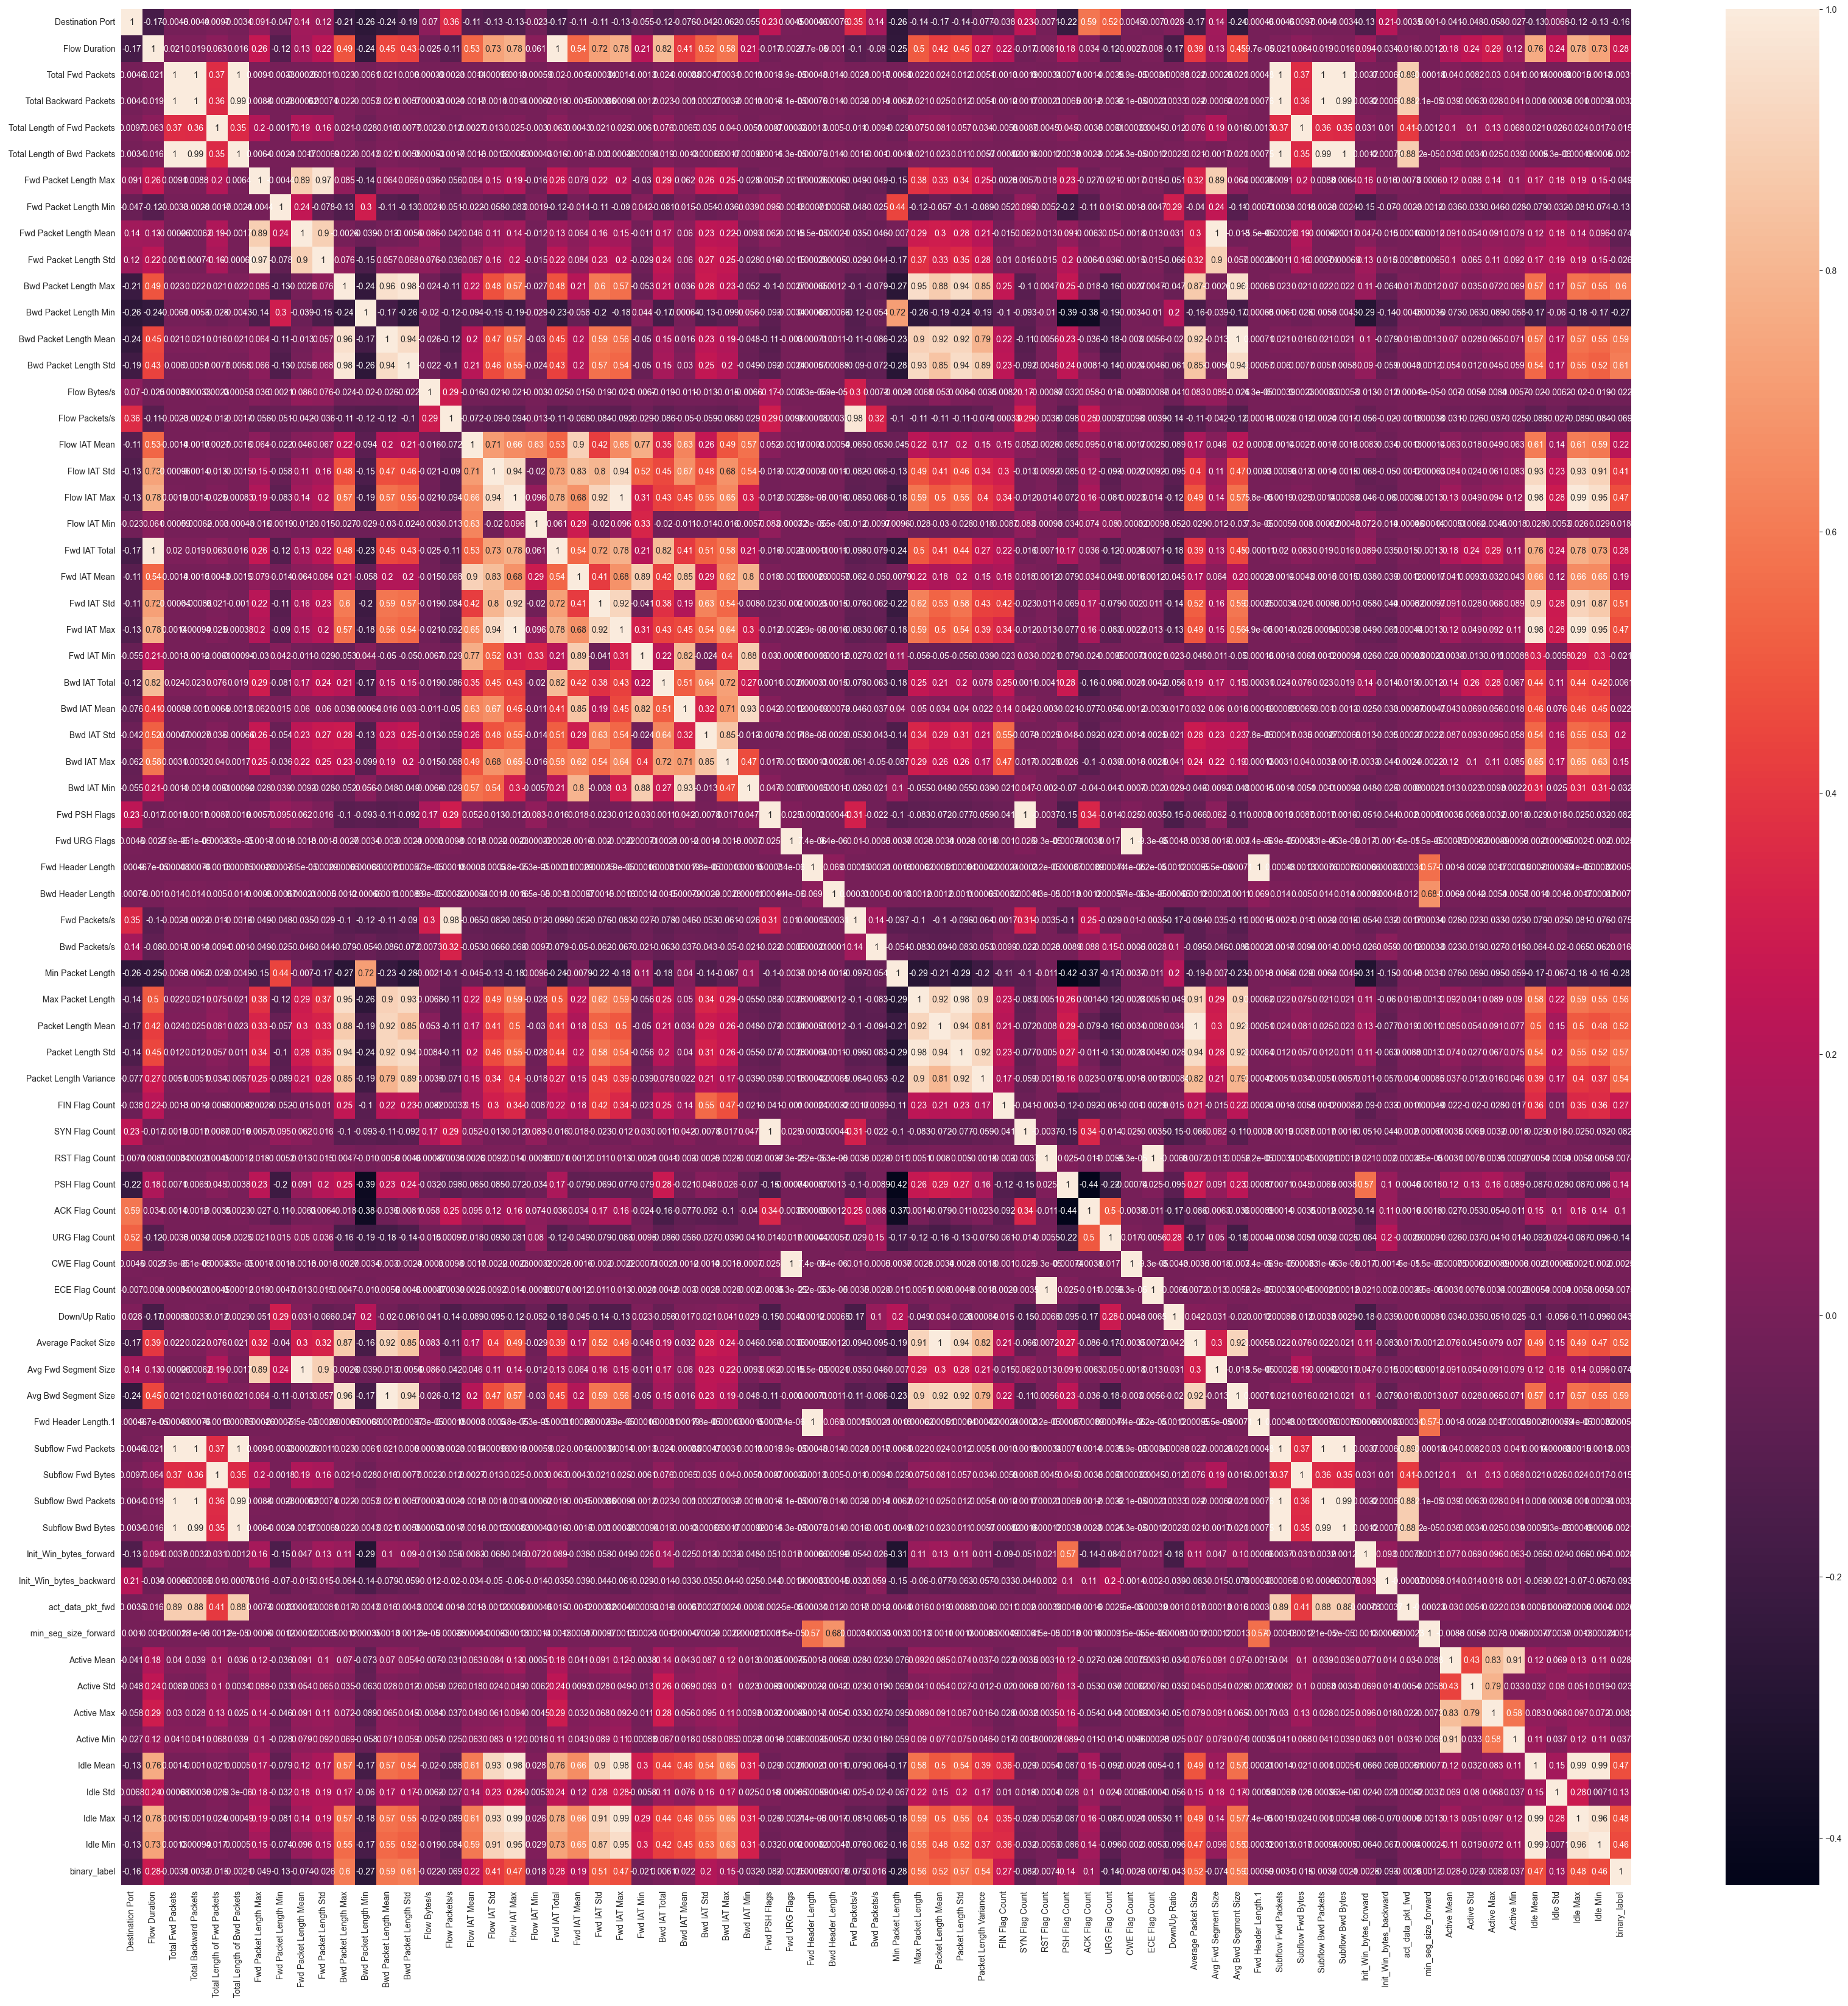

In [7]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(40, 40))
sns.heatmap(df_cleaned[numeric_cols].corr(), fmt='.2g', annot=True)

In [11]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

[' Destination Port',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Fwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std',
 ' Packet Length Variance',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' PSH Flag Count',
 ' ACK Flag Count',
 '

In [12]:
def correlation(a, b):
    return np.corrcoef(a, b)[0, 1]

scores = {}
y_crr = df_cleaned['binary_label']
X_corr = df_cleaned.drop(columns=['binary_label', ' Label'])
for col in X_corr.columns:
    try:
        r_cf = abs(correlation(X_corr[col], y_crr))   # korelacja z klasą
        scores[col] = r_cf
    except:
        scores[col] = 0

ranking = sorted(scores.items(), key=lambda x: x[1], reverse=True)

print("TOP 20 najważniejszych cech:")
for i, (f, s) in enumerate(ranking, 1):
    print(f"{i:2d}. {f:30s}  CFS-score = {s:.4f}")

TOP 20 najważniejszych cech:
 1.  Bwd Packet Length Std          CFS-score = 0.6117
 2. Bwd Packet Length Max           CFS-score = 0.5965
 3.  Bwd Packet Length Mean         CFS-score = 0.5944
 4.  Avg Bwd Segment Size           CFS-score = 0.5944
 5.  Packet Length Std              CFS-score = 0.5735
 6.  Max Packet Length              CFS-score = 0.5555
 7.  Packet Length Variance         CFS-score = 0.5368
 8.  Average Packet Size            CFS-score = 0.5216
 9.  Packet Length Mean             CFS-score = 0.5209
10.  Fwd IAT Std                    CFS-score = 0.5061
11.  Idle Max                       CFS-score = 0.4756
12.  Flow IAT Max                   CFS-score = 0.4715
13. Idle Mean                       CFS-score = 0.4709
14.  Fwd IAT Max                    CFS-score = 0.4708
15.  Idle Min                       CFS-score = 0.4584
16.  Flow IAT Std                   CFS-score = 0.4110
17. Fwd IAT Total                   CFS-score = 0.2801
18.  Flow Duration                  

In [17]:
#zostaw kolumny z korelecja powyzej 0.4
X_corr = X_corr[ [f for f, s in ranking if s > 0.4] ]
X_corr

,Bwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Mean,Avg Bwd Segment Size,Packet Length Std,Max Packet Length,Packet Length Variance,Average Packet Size,Packet Length Mean,Fwd IAT Std,Idle Max,Flow IAT Max,Idle Mean,Fwd IAT Max,Idle Min,Flow IAT Std
0,0.0,0,0.0,0.0,0.000000,6,0.00000,9.000000,6.000000,0.000,0,3,0.0,3,0,0.00000
1,0.0,6,6.0,6.0,0.000000,6,0.00000,9.000000,6.000000,0.000,0,109,0.0,0,0,0.00000
2,0.0,6,6.0,6.0,0.000000,6,0.00000,9.000000,6.000000,0.000,0,52,0.0,0,0,0.00000
3,0.0,6,6.0,6.0,0.000000,6,0.00000,9.000000,6.000000,0.000,0,34,0.0,0,0,0.00000
4,0.0,0,0.0,0.0,0.000000,6,0.00000,9.000000,6.000000,0.000,0,3,0.0,3,0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520793,0.0,76,76.0,76.0,23.421602,76,548.57140,48.666668,41.714287,17755.844,0,30780,0.0,30780,0,13617.57900
2520794,0.0,181,181.0,181.0,76.133440,181,5796.30000,122.000000,97.600000,0.000,0,320,0.0,2,0,183.59738
2520795,0.0,6,6.0,6.0,16.350330,31,267.33334,22.666666,17.000000,0.000,0,78,0.0,4,0,52.32590
2520796,0.0,128,128.0,128.0,42.332020,128,1792.00000,60.000000,53.333332,444210.060,0,1000947,0.0,1000947,0,375521.03000


PCA

In [32]:
Y_df_clean = df_cleaned['binary_label']
X_df_clean = df_cleaned.drop(columns=['binary_label', ' Label'])

In [33]:
pca = PCA(n_components=30)
principal_components = pca.fit_transform(X_df_clean)

In [34]:
df_pca = pca.transform(X_df_clean)
df_pca = pd.DataFrame(data=df_pca, columns=[f'PC{i+1}' for i in range(df_pca.shape[1])])
df_pca['binary_label'] = Y_df_clean.values
display(df_pca)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,binary_label
0,-3.459328e+07,-2.996206e+06,37160.960598,2.229918e+06,1.078970e+06,-671776.327080,354497.587535,-192444.742587,72620.287003,-209911.102024,128492.011266,46131.172217,109688.682763,333209.348776,21444.819300,-271895.023795,71228.475532,-15306.282819,-40669.971609,-19397.971810,512.199397,39166.665072,8731.174186,9481.525825,853716.423596,486.618507,2917.894156,-6.704026,-22.369688,-46977.278431,0
1,-3.455576e+07,-2.944846e+06,36735.152543,-1.662230e+06,1.097159e+06,-678776.322335,357208.626668,-193606.881004,73329.831064,-210373.982784,128806.534893,45915.960909,108862.157795,329169.511920,21219.563499,-264311.080170,69834.027265,-14762.264492,-36665.554103,-16287.271218,526.282553,29723.986604,6416.673238,4897.968444,-55917.939261,-697.096876,-6797.477111,-366.622460,301.089377,4353.412106,0
2,-3.455697e+07,-2.946438e+06,36747.493747,-1.541506e+06,1.096606e+06,-678579.178168,357146.257601,-193619.847631,73304.637684,-210350.634849,128807.283795,45876.783596,108886.168232,329316.214904,21228.359562,-264499.479483,69875.000975,-14764.654802,-36775.920978,-16360.144488,526.025006,29951.556160,6471.956089,5009.828224,-34450.627789,-670.338021,-6579.347142,-359.121745,295.475005,15729.008695,0
3,-3.455816e+07,-2.948050e+06,36759.975785,-1.419286e+06,1.096037e+06,-678363.164937,357066.575559,-193594.916469,73279.530315,-210326.964690,128794.796829,45869.096669,108901.840801,329418.774728,21234.335620,-264691.062027,69908.365735,-14774.188745,-36873.123409,-16433.573637,525.701492,30176.510525,6535.128350,5119.656530,-12928.673002,-640.425787,-6331.984768,-342.192428,296.670362,27045.100262,0
4,-3.459328e+07,-2.996206e+06,37160.960597,2.229918e+06,1.078970e+06,-671776.326908,354497.587715,-192444.742735,72620.286850,-209911.101583,128492.011452,46131.172260,109688.682643,333209.348903,21444.819280,-271895.023260,71228.475344,-15306.283246,-40669.970416,-19397.972650,512.199358,39166.664787,8731.176084,9481.524692,853716.377732,486.619148,2917.894997,-6.701633,-22.362470,-46977.322553,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520793,-3.450361e+07,-2.944908e+06,36789.829680,-1.763849e+06,1.080501e+06,-665276.431790,334839.774535,-183810.141069,65126.167562,-188372.466579,116545.702861,36830.045262,110006.065666,325097.257111,20945.951681,-264752.825398,66548.585020,-15335.265780,-35460.644189,-16276.042185,503.108917,28904.156062,6293.140478,4719.848890,-76507.808522,-716.947794,-6849.170997,-284.686734,412.832692,-7206.318327,0
2520794,-3.456761e+07,-2.961576e+06,36892.420927,-3.959893e+05,1.091058e+06,-676441.252113,356076.764187,-193184.090911,73435.037075,-209562.269803,128651.957677,45466.733511,108472.744760,327261.509783,21142.815038,-258965.392754,69911.062670,-14748.868281,-36351.341626,-16153.178266,517.502232,29425.538796,6523.887434,4821.466742,-67578.218640,-683.172963,-6698.635909,-307.834672,324.203281,-135.841026,0
2520795,-3.455904e+07,-2.949343e+06,36832.399261,-1.321081e+06,1.095558e+06,-678164.065836,356963.598118,-193559.646876,73238.675803,-210244.020461,128756.769589,45802.235107,108810.378433,329137.874172,21223.182345,-264318.455362,69848.983975,-14761.518634,-36747.835637,-16356.402491,535.329830,29942.748692,6469.377447,5014.201518,-33108.320529,-668.530119,-6558.709703,-361.191685,284.111349,7113.307013,0
2520796,-3.290957e+07,-2.952395e+06,36265.176873,-1.761147e+06,5.015506e+05,-259825.881481,-345934.104254,80075.361944,-155630.791938,397501.230768,-378581.610335,-224477.161937,101334.837152,220463.392056,13569.652774,-295868.246466,51154.117556,-19066.984823,3415.903282,-21077.356054,449.237044,25219.627009,-1586.943509,-2933.985819,-73464.102481,-1587.236168,-14313.091155,577.937263,5886.202745,-6992.436796,0


Zapisz dane po PCA

In [35]:
df_pca.to_csv('./MachineLearningCVE/pca_transformed_dataset_30.csv', index=False)

<Axes: >

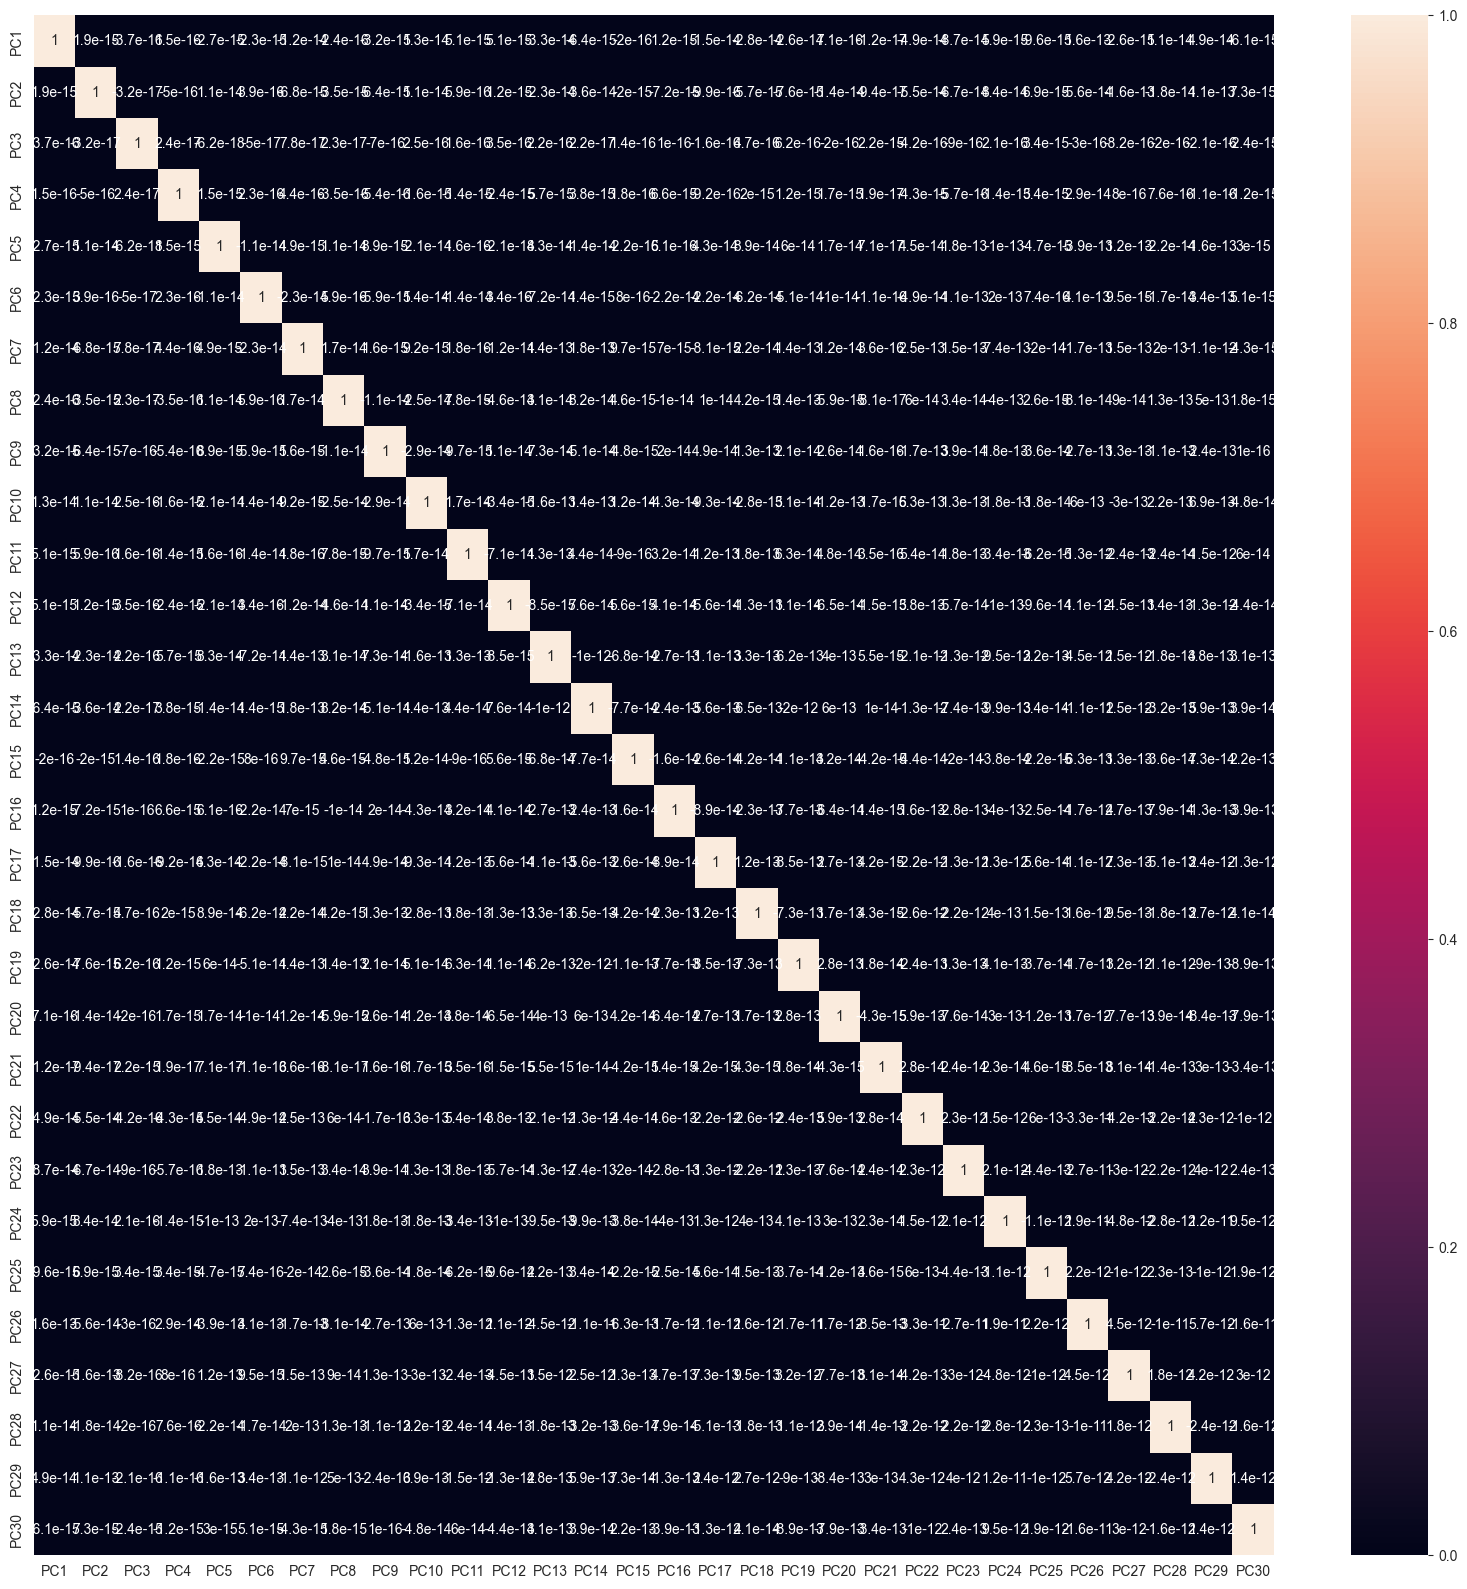

In [36]:
plt.figure(figsize=(20, 20))
sns.heatmap(df_pca.drop(columns=['binary_label']).corr(), fmt='.2g', annot=True)

#### PCA dla 2 wymiarów

C:\Users\zuzka\AppData\Local\Temp\ipykernel_27468\695257191.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(classes))
s:\PWR\PNW\PNW2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


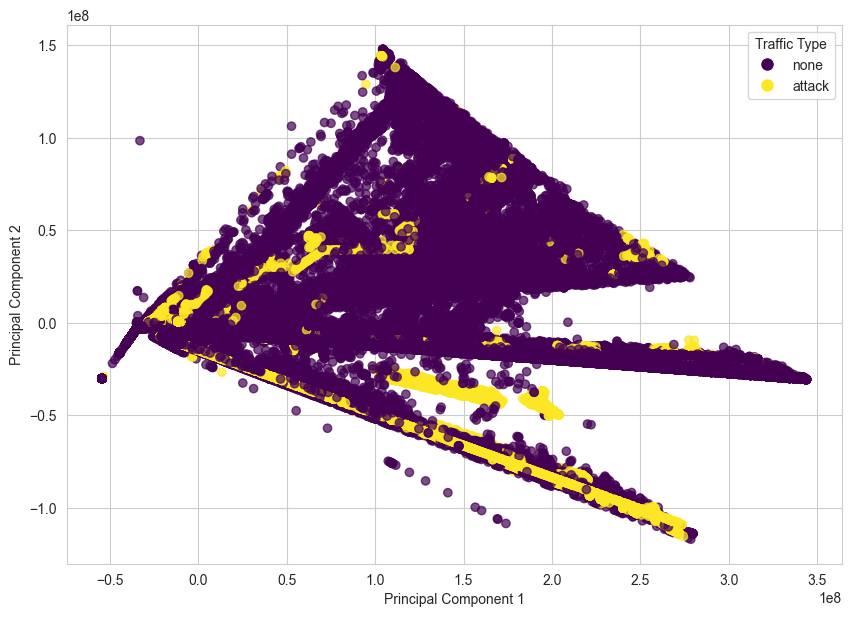

In [ ]:
pca2 = PCA(n_components=2)
principal_components = pca2.fit_transform(X_df_clean)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    c=Y_df_clean,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')


labels = {
    0: 'none',
    1: 'attack'
}

classes = np.unique(Y_df_clean)

cmap = plt.cm.get_cmap('viridis', len(classes))
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(i), markersize=10,
               label=labels[cls])
    for i, cls in enumerate(classes)
]

plt.legend(handles=handles, title="Traffic Type")

plt.show()

## Definicja modelu Autoencoder

Definiujemy prosty model autoenkodera przy użyciu Keras. Składać się będzie z warstwy kodującej i dekodującej.

In [ ]:
def create_autoencoder(input_dim, encoding_dim_ratio=0.5, intermediate_dim_ratio=0.75):
    """
    Tworzy model autoenkodera.
    input_dim: liczba cech wejściowych.
    encoding_dim_ratio: stosunek wymiaru warstwy kodującej do wymiaru wejściowego.
    intermediate_dim_ratio: stosunek wymiaru warstwy pośredniej do wymiaru wejściowego.
    """
    encoding_dim = max(2, int(input_dim * encoding_dim_ratio))
    intermediate_dim = max(encoding_dim +1 , int(input_dim * intermediate_dim_ratio))

    # Input -> Dense (intermediate) -> Dense (encoding) -> Dense (intermediate) -> Output
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(intermediate_dim, activation='relu', name='encoder_intermediate'),
        Dense(encoding_dim, activation='relu', name='encoder_bottleneck'),
        Dense(intermediate_dim, activation='relu', name='decoder_intermediate'),
        Dense(input_dim, activation='sigmoid', name='decoder_output')
    ], name="Autoencoder")
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    print(f"Autoencoder: Input({input_dim}) -> {intermediate_dim} -> {encoding_dim} -> {intermediate_dim} -> {input_dim}")
    return model

_test_ae = create_autoencoder(X.shape[1])
_test_ae.summary()
del _test_ae
print("Definicja Autoenkodera gotowa.")

In [ ]:
def create_autoencoder2(input_dim, encoding_dim_ratio=0.5, intermediate_dim_ratio=0.75):
    """
    Tworzy model autoenkodera z dodatkowymi warstwami BatchNormalization i Dropout.
    input_dim: liczba cech wejściowych.
    encoding_dim_ratio: stosunek wymiaru warstwy kodującej do wymiaru wejściowego.
    intermediate_dim_ratio: stosunek wymiaru warstwy pośredniej do wymiaru wejściowego.
    """
    encoding_dim = int(input_dim * encoding_dim_ratio)
    intermediate_dim = max(encoding_dim + 1, int(input_dim * intermediate_dim_ratio))
    intermediate_dim = min(intermediate_dim, input_dim - 1)

    # Encoder
    encoder_input = Input(shape=(input_dim,))
    x = Dense(intermediate_dim, activation='relu', name='encoder_intermediate_1')(encoder_input)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(encoding_dim, activation='relu', name='encoder_bottleneck')(x)
    encoder_output = BatchNormalization()(x)

    # Decoder
    x = Dense(intermediate_dim, activation='relu', name='decoder_intermediate_1')(encoder_output)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    decoder_output = Dense(input_dim, activation='linear', name='decoder_output')(x)

    model = Model(inputs=encoder_input, outputs=decoder_output, name="Autoencoder")

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    print(f"Autoencoder: Input({input_dim}) -> {intermediate_dim} -> {encoding_dim} -> {intermediate_dim} -> {input_dim}")
    return model

_test_ae = create_autoencoder2(X.shape[1])
_test_ae.summary()
del _test_ae
print("Definicja Autoenkodera2 gotowa.")

## 1.2 Wybór hyperparametrów 

In [6]:
df_pca = pd.read_csv('./MachineLearningCVE/pca_transformed_dataset.csv', low_memory=False)
display(df_pca)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,binary_label
0,-3.459328e+07,-2.996206e+06,37160.960589,2.229918e+06,1.078970e+06,-671776.327082,354497.587541,-192444.742586,72620.287259,-209911.101883,128492.011355,46131.172250,109688.682701,333209.348987,21444.819284,-271895.024007,71228.475545,-15306.282847,-40669.971672,0
1,-3.455576e+07,-2.944846e+06,36735.152543,-1.662230e+06,1.097159e+06,-678776.322405,357208.626690,-193606.881007,73329.831320,-210373.982627,128806.534971,45915.960929,108862.157698,329169.511990,21219.563475,-264311.080173,69834.027234,-14762.264502,-36665.554062,0
2,-3.455697e+07,-2.946438e+06,36747.493746,-1.541506e+06,1.096606e+06,-678579.178241,357146.257625,-193619.847635,73304.637941,-210350.634694,128807.283874,45876.783616,108886.168137,329316.214981,21228.359538,-264499.479493,69875.000946,-14764.654814,-36775.920942,0
3,-3.455816e+07,-2.948050e+06,36759.975786,-1.419286e+06,1.096037e+06,-678363.164976,357066.575568,-193594.916465,73279.530567,-210326.964526,128794.796901,45869.096688,108901.840699,329418.774785,21234.335595,-264691.062033,69908.365698,-14774.188755,-36873.123364,0
4,-3.459328e+07,-2.996206e+06,37160.960588,2.229918e+06,1.078970e+06,-671776.326910,354497.587721,-192444.742735,72620.287106,-209911.101441,128492.011540,46131.172293,109688.682581,333209.349114,21444.819264,-271895.023472,71228.475357,-15306.283273,-40669.970479,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520793,-3.450361e+07,-2.944908e+06,36789.829681,-1.763849e+06,1.080501e+06,-665276.431920,334839.774533,-183810.141062,65126.167752,-188372.466339,116545.702967,36830.045339,110006.065672,325097.257201,20945.951657,-264752.825400,66548.584904,-15335.265800,-35460.644266,0
2520794,-3.456761e+07,-2.961576e+06,36892.420919,-3.959894e+05,1.091058e+06,-676441.252253,356076.764237,-193184.090931,73435.037341,-209562.269660,128651.957775,45466.733526,108472.744676,327261.509842,21142.815014,-258965.392565,69911.062659,-14748.868293,-36351.341584,0
2520795,-3.455904e+07,-2.949343e+06,36832.399260,-1.321081e+06,1.095558e+06,-678164.065897,356963.598137,-193559.646877,73238.676058,-210244.020302,128756.769664,45802.235127,108810.378334,329137.874238,21223.182321,-264318.455370,69848.983942,-14761.518644,-36747.835595,0
2520796,-3.290957e+07,-2.952395e+06,36265.176874,-1.761147e+06,5.015506e+05,-259825.878993,-345934.104277,80075.363906,-155630.792178,397501.229814,-378581.609065,-224477.162926,101334.836717,220463.392972,13569.652821,-295868.246391,51154.117221,-19066.984763,3415.901225,0


In [37]:
old_memory_usage = df_pca.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df_pca.columns:
    col_type = df_pca[col].dtype
    if col_type != object:
        c_min = df_pca[col].min()
        c_max = df_pca[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df_pca[col] = df_pca[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df_pca[col] = df_pca[col].astype(np.int32)
new_memory_usage = df_pca.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Initial memory usage: 586.58 MB
Final memory usage: 298.10 MB
Reduced memory usage: 49.18%


In [38]:
display(df_pca)
old_memory_usage = df_pca.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,binary_label
0,-34593284.0,-2996206.25,37160.960938,2.229918e+06,1.078970e+06,-671776.3125,354497.59375,-192444.750000,72620.289062,-209911.109375,128492.007812,46131.171875,109688.679688,333209.343750,21444.818359,-271895.031250,71228.476562,-15306.283203,-40669.972656,-19397.972656,512.199402,39166.664062,8731.173828,9481.525391,853716.437500,486.618500,2917.894043,-6.704026,-22.369688,-46977.277344,0
1,-34555764.0,-2944845.75,36735.152344,-1.662230e+06,1.097159e+06,-678776.3125,357208.62500,-193606.875000,73329.828125,-210373.984375,128806.531250,45915.960938,108862.156250,329169.500000,21219.564453,-264311.093750,69834.023438,-14762.264648,-36665.554688,-16287.271484,526.282532,29723.986328,6416.673340,4897.968262,-55917.937500,-697.096863,-6797.477051,-366.622467,301.089386,4353.412109,0
2,-34556968.0,-2946438.00,36747.492188,-1.541506e+06,1.096606e+06,-678579.1875,357146.25000,-193619.843750,73304.640625,-210350.640625,128807.281250,45876.785156,108886.171875,329316.218750,21228.359375,-264499.468750,69875.000000,-14764.655273,-36775.921875,-16360.144531,526.025024,29951.556641,6471.956055,5009.828125,-34450.628906,-670.338013,-6579.347168,-359.121735,295.475006,15729.008789,0
3,-34558156.0,-2948049.75,36759.976562,-1.419286e+06,1.096037e+06,-678363.1875,357066.56250,-193594.921875,73279.531250,-210326.968750,128794.796875,45869.097656,108901.843750,329418.781250,21234.335938,-264691.062500,69908.367188,-14774.188477,-36873.125000,-16433.574219,525.701477,30176.509766,6535.128418,5119.656738,-12928.672852,-640.425781,-6331.984863,-342.192413,296.670349,27045.099609,0
4,-34593284.0,-2996206.25,37160.960938,2.229918e+06,1.078970e+06,-671776.3125,354497.59375,-192444.750000,72620.289062,-209911.109375,128492.007812,46131.171875,109688.679688,333209.343750,21444.818359,-271895.031250,71228.476562,-15306.283203,-40669.968750,-19397.972656,512.199341,39166.664062,8731.175781,9481.524414,853716.375000,486.619141,2917.895020,-6.701633,-22.362471,-46977.324219,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520793,-34503612.0,-2944908.50,36789.828125,-1.763849e+06,1.080501e+06,-665276.4375,334839.78125,-183810.140625,65126.167969,-188372.468750,116545.703125,36830.046875,110006.062500,325097.250000,20945.951172,-264752.812500,66548.585938,-15335.265625,-35460.644531,-16276.041992,503.108917,28904.156250,6293.140625,4719.849121,-76507.804688,-716.947815,-6849.170898,-284.686737,412.832703,-7206.318359,0
2520794,-34567612.0,-2961575.50,36892.421875,-3.959893e+05,1.091058e+06,-676441.2500,356076.75000,-193184.093750,73435.039062,-209562.265625,128651.960938,45466.734375,108472.742188,327261.500000,21142.814453,-258965.390625,69911.062500,-14748.868164,-36351.339844,-16153.178711,517.502258,29425.539062,6523.887207,4821.466797,-67578.218750,-683.172974,-6698.635742,-307.834686,324.203278,-135.841019,0
2520795,-34559040.0,-2949343.50,36832.398438,-1.321081e+06,1.095558e+06,-678164.0625,356963.59375,-193559.640625,73238.679688,-210244.015625,128756.773438,45802.234375,108810.375000,329137.875000,21223.181641,-264318.468750,69848.984375,-14761.518555,-36747.835938,-16356.402344,535.329834,29942.748047,6469.377441,5014.201660,-33108.320312,-668.530090,-6558.709473,-361.191681,284.111359,7113.307129,0
2520796,-32909570.0,-2952395.50,36265.175781,-1.761146e+06,5.015506e+05,-259825.8750,-345934.09375,80075.359375,-155630.796875,397501.218750,-378581.625000,-224477.156250,101334.835938,220463.390625,13569.652344,-295868.250000,51154.117188,-19066.984375,3415.903320,-21077.355469,449.237030,25219.626953,-1586.943481,-2933.985840,-73464.101562,-1587.236206,-14313.090820,577.937256,5886.202637,-6992.437012,0


Initial memory usage: 298.10 MB


In [12]:
#normalize data of df_pca
df_cleaned = df_cleaned.drop(columns=[' Label'])
scaler = QuantileTransformer(output_distribution='normal')
scaled_features = scaler.fit_transform(df_cleaned.drop(columns=['binary_label']))
df_cleaned_scaled = pd.DataFrame(scaled_features, columns=df_cleaned.columns[:-1])
df_cleaned_scaled['binary_label'] = df_cleaned['binary_label'].values
display(df_cleaned_scaled)
scaled_memory_usage = df_cleaned_scaled.memory_usage().sum() / 1024 ** 2
print(f'Scaled memory usage: {scaled_memory_usage:.2f} MB')

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,binary_label
0,1.594914,-2.119668,-0.232930,-5.199338,-0.751333,-5.199338,-0.779924,0.176553,-0.752997,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,1.968165,2.063775,-2.023292,-5.199338,-2.085356,-0.423855,-0.406079,-0.393847,-5.199338,-0.401995,-0.042668,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-0.530745,-5.199338,2.096521,-5.199338,0.193143,-0.880888,-0.746351,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-0.691121,-0.752997,-5.199338,-0.530745,-0.232930,-0.751333,-5.199338,-5.199338,-0.238924,-5.199338,-0.042668,-0.656486,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,0
1,1.609470,-0.948812,-5.199338,-0.647177,-0.905189,-0.650274,-0.779924,0.176553,-0.752997,-5.199338,-0.613509,0.179102,-0.601439,-5.199338,0.691689,0.697500,-0.584984,-5.199338,-0.914679,0.832526,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-1.679303,-0.858910,0.665845,0.864357,0.193143,-0.880888,-0.746351,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,5.199338,5.199338,-5.199338,-5.199338,0.426601,-0.691121,-0.752997,-0.601439,-1.679303,-5.199338,-0.905189,-0.647177,-0.650274,-0.254902,0.901416,-5.199338,-0.656486,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,0
2,1.609524,-1.269664,-5.199338,-0.647177,-0.905189,-0.650274,-0.779924,0.176553,-0.752997,-5.199338,-0.613509,0.179102,-0.601439,-5.199338,0.866072,1.197193,-1.125776,-5.199338,-1.212751,0.552537,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-1.679303,-0.858910,1.181921,1.471555,0.193143,-0.880888,-0.746351,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,5.199338,5.199338,-5.199338,-5.199338,0.426601,-0.691121,-0.752997,-0.601439,-1.679303,-5.199338,-0.905189,-0.647177,-0.650274,-0.254902,0.901416,-5.199338,-0.656486,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,0
3,1.181964,-1.497997,-5.199338,-0.647177,-0.905189,-0.650274,-0.779924,0.176553,-0.752997,-5.199338,-0.613509,0.179102,-0.601439,-5.199338,0.972785,1.418119,-1.358913,-5.199338,-1.475269,0.305796,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-1.679303,-0.858910,1.371657,1.761948,0.193143,-0.880888,-0.746351,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,5.199338,5.199338,-5.199338,-5.199338,0.426601,-0.691121,-0.752997,-0.601439,-1.679303,-5.199338,-0.905189,-0.647177,-0.650274,-0.245840,1.000509,-5.199338,-0.656486,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,0
4,1.594749,-2.119668,-0.232930,-5.199338,-0.751333,-5.19

Scaled memory usage: 1355.87 MB


In [55]:
# y = df_cleaned_scaled['binary_label']
# X = df_cleaned_scaled.drop(columns=['binary_label'])
y = y_crr
X = X_corr

In [22]:
global_contamination_rate = y.value_counts(normalize=True).get(1)
print(f"Globalny wpółczynnik anomalii w zbiorze do strojenia: {global_contamination_rate:.2%}")

Globalny wpółczynnik anomalii w zbiorze do strojenia: 16.89%


In [15]:
test_size_for_tuning = 0.20

X, X_tuning_set, y, y_tuning_set = train_test_split(
    X, y, test_size=test_size_for_tuning, random_state=RANDOM_STATE, stratify=y
)

print(f"Zbiór CV: {X.shape}, Zbiór do strojenia: {X_tuning_set.shape}")

Zbiór CV: (2016638, 70), Zbiór do strojenia: (504160, 70)


### Isolation forest
- n_estimators: Liczba drzew bazowych w ensemblu.

- max_samples: Liczba próbek losowanych do trenowania każdego drzewa.

- contamination: Oczekiwany odsetek anomalii w zbiorze danych.

- max_features: Liczba cech losowanych do rozważenia przy szukaniu najlepszego podziału w węźle drzewa.


IF, OCSVM: im niższy score, tym bardziej model uważa próbkę za anomalię.

roc_auc_score zakłada, że wyższy score = większe prawdopodobieństwo klasy pozytywnej (tu: ataku).

Dlatego odwraca się znaki: -y_pred_scores, żeby "najbardziej anomalia" miała najwyższy score dla AUC

In [ ]:
model_name = "IsolationForest"
n_iter = 15

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_samples': [256, 512, 'auto'],
    'contamination': [global_contamination_rate],
    'max_features': [0.5, 0.7, 1.0]
}

scalers = {
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'QuantileTransformer': QuantileTransformer(output_distribution='normal')
}

all_param_combinations = list(product(*param_grid.values()))
random.shuffle(all_param_combinations)
random_combinations = all_param_combinations[:n_iter]

best_auc_total = 0
best_params_total = None
best_scaler_total = None

scaler_win_counts = {name: 0 for name in scalers}

K = 3
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_tuning_set, y_tuning_set)):
    print(f"\n====================== {model_name} === FOLD {fold_idx}/{K} ==============================")

    X_train_raw, y_train_raw = X_tuning_set.iloc[train_idx], y_tuning_set.iloc[train_idx]
    X_test, y_test = X_tuning_set.iloc[test_idx], y_tuning_set.iloc[test_idx]

    X_train = X_train_raw[y_train_raw == 0]  # tylko normalne
    print(f"Rozmiar X_train: {X_train.shape}, Rozmiar X_test: {X_test.shape}, Normalne w teście: {(y_test==0).sum()}, Anomalie: {(y_test==1).sum()}")

    best_auc = 0
    best_params = None
    best_scaler_name = None
    best_scaler_obj = None

    for scaler_name, scaler in scalers.items():
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        for i, combo in enumerate(random_combinations):
            params = dict(zip(param_grid.keys(), combo))
            print(f"[{scaler_name}] {i+1}/{n_iter} Sprawdzanie parametrów: {params}")

            model = IsolationForest(random_state=RANDOM_STATE, n_jobs=-1, **params)
            model.fit(X_train_scaled)
            y_pred = model.predict(X_test_scaled)
            scores = -model.decision_function(X_test_scaled)

            auc = roc_auc_score(y_test, scores)

            if auc > best_auc:
                best_auc = auc
                best_params = params
                best_scaler_name = scaler_name
                best_scaler_obj = scaler

            if auc > best_auc_total:
                best_auc_total = auc
                best_params_total = params
                best_scaler_total = scaler_name

    print(f"\nNajlepszy skaler w foldzie: {best_scaler_name}")
    print(f"Najlepsze parametry w foldzie ({best_scaler_name}): {best_params}")
    print(f"Najlepszy wynik AUC w foldzie ({best_scaler_name}): {best_auc:.4f}")
    scaler_win_counts[best_scaler_name] += 1

    # Ostateczne dopasowanie i ocena dla najlepszego skalera i parametrów
    X_train_scaled = best_scaler_obj.fit_transform(X_train)
    X_test_scaled = best_scaler_obj.transform(X_test)

    model = IsolationForest(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
    model.fit(X_train_scaled)
    y_pred = model.predict(X_test_scaled)
    scores = -model.decision_function(X_test_scaled)
    y_pred_bin = [1 if x == -1 else 0 for x in y_pred]

    precision = precision_score(y_test, y_pred_bin, zero_division=0)
    recall = recall_score(y_test, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_test, scores)

    print(f"    {model_name} - F1: {f1:.4f}, AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {fpr:.4f}")


print("\n--- Zakończono walidację krzyżową ---")
print(f"Najlepsze globalne parametry: {best_params_total}")
print(f"Najlepszy globalny wynik AUC: {best_auc_total:.4f}")
print(f"Najlepszy globalnie skaler: {best_scaler_total}")
print(f"\nLiczba zwycięstw skalera (foldów):")
for name, count in scaler_win_counts.items():
    print(f"  {name}: {count}x")

### OC-SVM
- kernel: Typ jądra używanego w algorytmie, może to być'rbf' (Radial Basis Function), 'linear', 'poly', 'sigmoid', ‘precomputed’.

- nu: Parametr z zakresu (0, 1], który stanowi górne ograniczenie na frakcję błędów treningowych (próbek normalnych sklasyfikowanych jako anomalie) oraz dolne ograniczenie na frakcję wektorów wsparcia, domyślnie 0.5

- gamma: Współczynnik jądra dla 'rbf', 'poly' i 'sigmoid'. Definiuje, jak duży wpływ ma pojedyncza próbka treningowa.

In [11]:
model_name = "OneClassSVM"
n_iter = 10

nu_options = [0.01, 0.05, 0.1, 0.15, 0.2]
nu_options.append(global_contamination_rate)
nu_options = sorted(list(set(nu_options)))

param_grid = {
    'kernel': ['rbf'],
    'nu': nu_options,
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
}

scalers = {
    # 'RobustScaler': RobustScaler(),
    # 'StandardScaler': StandardScaler(),
    # 'MinMaxScaler': MinMaxScaler(),
    'QuantileTransformer': QuantileTransformer(output_distribution='normal')
}

all_param_combinations = list(product(*param_grid.values()))
random.shuffle(all_param_combinations)
random_combinations = all_param_combinations[:n_iter]

best_auc_total = 0
best_params_total = None
best_scaler_total = None

scaler_win_counts = {name: 0 for name in scalers}

K = 2
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_tuning_set, y_tuning_set)):
    print(f"\n====================== {model_name} === FOLD {fold_idx + 1}/{K} ==============================")

    X_train_raw, y_train_raw = X_tuning_set.iloc[train_idx], y_tuning_set.iloc[train_idx]
    X_test, y_test = X_tuning_set.iloc[test_idx], y_tuning_set.iloc[test_idx]

    X_train = X_train_raw[y_train_raw == 0]
    print(f"Size of X_train: {X_train.shape}, Size of X_test: {X_test.shape}, Normal in test: {(y_test==0).sum()}, Anomalies: {(y_test==1).sum()}")

    best_auc = 0
    best_params = None
    best_scaler_name = None
    best_scaler_obj = None

    for scaler_name, scaler in scalers.items():
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        for i, combo in enumerate(random_combinations):
            params = dict(zip(param_grid.keys(), combo))
            print(f"[{scaler_name}] {i+1}/{n_iter} Checking params: {params}")

            model = OneClassSVM(tol=0.01, verbose=False, cache_size=500, **params)
            model.fit(X_train_scaled)

            scores = -model.decision_function(X_test_scaled)
            auc = roc_auc_score(y_test, scores)

            if auc > best_auc:
                best_auc = auc
                best_params = params
                best_scaler_name = scaler_name
                best_scaler_obj = scaler

            if auc > best_auc_total:
                best_auc_total = auc
                best_params_total = params
                best_scaler_total = scaler_name

    print(f"\nBest scaler in fold: {best_scaler_name}")
    print(f"Best params in fold ({best_scaler_name}): {best_params}")
    print(f"Best AUC score in fold ({best_scaler_name}): {best_auc:.4f}")
    scaler_win_counts[best_scaler_name] += 1

    X_train_scaled = best_scaler_obj.fit_transform(X_train)
    X_test_scaled = best_scaler_obj.transform(X_test)

    model = OneClassSVM(tol=0.01, verbose=False, cache_size=500, **best_params)
    model.fit(X_train_scaled)
    y_pred = model.predict(X_test_scaled)
    scores = -model.decision_function(X_test_scaled)

    # Convert predictions (-1 for anomaly, 1 for normal) to binary (1 for anomaly, 0 for normal)
    y_pred_bin = [1 if x == -1 else 0 for x in y_pred]

    precision = precision_score(y_test, y_pred_bin, zero_division=0)
    recall = recall_score(y_test, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_test, scores)

    print(f"    {model_name} - F1: {f1:.4f}, AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {fpr:.4f}")


print("\n--- Cross-validation finished ---")
print(f"Best global parameters: {best_params_total}")
print(f"Best global AUC score: {best_auc_total:.4f}")
print(f"Best global scaler: {best_scaler_total}")
print(f"\nScaler win counts (by fold):")
for name, count in scaler_win_counts.items():
    print(f"  {name}: {count}x")


====================== OneClassSVM === FOLD 1/2 ==============================
Size of X_train: (209506, 19), Size of X_test: (252080, 19), Normal in test: 209506, Anomalies: 42574
[QuantileTransformer] 1/10 Checking params: {'kernel': 'rbf', 'nu': 0.15, 'gamma': 1.0}
[QuantileTransformer] 2/10 Checking params: {'kernel': 'rbf', 'nu': 0.2, 'gamma': 0.001}
[QuantileTransformer] 3/10 Checking params: {'kernel': 'rbf', 'nu': np.float64(0.16889135900615598), 'gamma': 1.0}
[QuantileTransformer] 4/10 Checking params: {'kernel': 'rbf', 'nu': 0.01, 'gamma': 0.01}
[QuantileTransformer] 5/10 Checking params: {'kernel': 'rbf', 'nu': 0.2, 'gamma': 'auto'}
[QuantileTransformer] 6/10 Checking params: {'kernel': 'rbf', 'nu': 0.2, 'gamma': 1.0}
[QuantileTransformer] 7/10 Checking params: {'kernel': 'rbf', 'nu': np.float64(0.16889135900615598), 'gamma': 0.1}
[QuantileTransformer] 8/10 Checking params: {'kernel': 'rbf', 'nu': 0.2, 'gamma': 0.01}
[QuantileTransformer] 9/10 Checking params: {'kernel': 'r

### AE

In [ ]:
def create_autoencoder(input_dim, encoding_dim_ratio=0.5, intermediate_dim_ratio=0.75, 
                       dropout_rate=0.2, learning_rate=0.001):
    """
    Tworzy model autoenkodera na podstawie podanych hiperparametrów.
    """
    encoding_dim = int(input_dim * encoding_dim_ratio)
    intermediate_dim = max(encoding_dim + 1, int(input_dim * intermediate_dim_ratio))
    intermediate_dim = min(intermediate_dim, input_dim - 1)
    
    # Zabezpieczenie przed zbyt małą wymiarowością
    if encoding_dim < 1: encoding_dim = 1
    if intermediate_dim <= encoding_dim: intermediate_dim = encoding_dim + 1
    if intermediate_dim >= input_dim: intermediate_dim = input_dim -1
    
    # Encoder
    encoder_input = Input(shape=(input_dim,))
    x = Dense(intermediate_dim, activation='relu')(encoder_input)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(encoding_dim, activation='relu')(x)
    encoder_output = BatchNormalization()(x)
    
    # Decoder
    x = Dense(intermediate_dim, activation='relu')(encoder_output)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    decoder_output = Dense(input_dim, activation='linear')(x)
    
    model = Model(inputs=encoder_input, outputs=decoder_output, name="Autoencoder")
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    # print(f"AE Architecture: Input({input_dim}) -> {intermediate_dim} -> {encoding_dim} -> {intermediate_dim} -> {input_dim}")
    return model

def find_optimal_threshold_youden(y_true, y_scores):
    """
    Znajduje optymalny próg detekcji na podstawie statystyki J Youdena.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    return optimal_threshold

In [ ]:
model_name = "Autoencoder"
n_iter = 2

param_grid = {
    'encoding_dim_ratio': [0.1, 0.25, 0.5],
    'intermediate_dim_ratio': [0.5, 0.75],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [0.01, 0.001],
    'batch_size': [32, 64],
    'epochs': [1, 2] # Dodajemy epoki do strojenia
}

scalers = {
    # 'RobustScaler': RobustScaler(),
    # 'StandardScaler': StandardScaler(),
    # 'MinMaxScaler': MinMaxScaler(),
    'QuantileTransformer': QuantileTransformer(output_distribution='normal')
}

all_param_combinations = list(product(*param_grid.values()))
random.shuffle(all_param_combinations)
random_combinations = all_param_combinations[:n_iter]

best_auc_total = 0
best_params_total = None
best_scaler_total = None

scaler_win_counts = {name: 0 for name in scalers}

K = 2
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_tuning_set, y_tuning_set)):
    print(f"\n====================== {model_name} === FOLD {fold_idx+1}/{K} ==============================")

    X_train_raw, y_train_raw = X_tuning_set.iloc[train_idx], y_tuning_set.iloc[train_idx]
    X_test, y_test = X_tuning_set.iloc[test_idx], y_tuning_set.iloc[test_idx]
    X_train = X_train_raw[y_train_raw == 0]
    print(f"Rozmiar X_train (tylko normalne): {X_train.shape}, Rozmiar X_test: {X_test.shape}, Normalne w teście: {(y_test==0).sum()}, Anomalie w teście: {(y_test==1).sum()}")

    best_auc = 0
    best_params_fold = None
    best_scaler_name_fold = None
    best_scaler_obj_fold = None

    for scaler_name, scaler in scalers.items():
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        input_dim = X_train_scaled.shape[1]

        for i, combo in enumerate(random_combinations):
            params = dict(zip(param_grid.keys(), combo))
            print(f"[{scaler_name}] {i+1}/{n_iter} Sprawdzanie: {params}")

            tf.keras.backend.clear_session()
            
            autoencoder = create_autoencoder(
                input_dim=input_dim,
                encoding_dim_ratio=params['encoding_dim_ratio'],
                intermediate_dim_ratio=params['intermediate_dim_ratio'],
                dropout_rate=params['dropout_rate'],
                learning_rate=params['learning_rate']
            )

            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min')

            autoencoder.fit(
                X_train_scaled, X_train_scaled,
                epochs=params['epochs'],
                batch_size=params['batch_size'],
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping],
                verbose=0  # Wyłączamy logowanie, żeby nie zaśmiecać wyjścia
            )

            X_test_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)
            mse_scores = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)
            auc = roc_auc_score(y_test, mse_scores)

            if auc > best_auc:
                best_auc = auc
                best_params_fold = params
                best_scaler_name_fold = scaler_name
                best_scaler_obj_fold = scaler

            if auc > best_auc_total:
                best_auc_total = auc
                best_params_total = params
                best_scaler_total = scaler_name
    
    print(f"\nNajlepszy skaler w foldzie: {best_scaler_name_fold}")
    print(f"Najlepsze parametry w foldzie: {best_params_fold}")
    print(f"Najlepszy wynik AUC w foldzie: {best_auc:.4f}")
    scaler_win_counts[best_scaler_name_fold] += 1

    print("\n--- Ocena najlepszego modelu dla folda z optymalnym progiem (Youden's J) ---")
    
    X_train_scaled = best_scaler_obj_fold.fit_transform(X_train)
    X_test_scaled = best_scaler_obj_fold.transform(X_test)
    input_dim = X_train_scaled.shape[1]

    tf.keras.backend.clear_session()
    final_model = create_autoencoder(
        input_dim=input_dim,
        **{k: v for k, v in best_params_fold.items() if k not in ['batch_size', 'epochs']}
    )
    final_model.fit(
        X_train_scaled, X_train_scaled,
        epochs=best_params_fold['epochs'],
        batch_size=best_params_fold['batch_size'],
        shuffle=True,
        verbose=0
    )

    # Predykcja i błędy rekonstrukcji
    y_scores_ae = np.mean(np.square(X_test_scaled - final_model.predict(X_test_scaled, verbose=0)), axis=1)

    # Znajdź optymalny próg i dokonaj predykcji
    optimal_threshold = find_optimal_threshold_youden(y_test, y_scores_ae)
    print(f"Optymalny próg (Youden's J) dla folda: {optimal_threshold:.4f}")
    y_pred_bin = (y_scores_ae > optimal_threshold).astype(int)

    precision = precision_score(y_test, y_pred_bin, zero_division=0)
    recall = recall_score(y_test, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_test, y_scores_ae) # AUC liczymy na score'ach, nie na binarnej predykcji

    print(f"    Metryki dla folda - F1: {f1:.4f}, AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {fpr:.4f}")


print("\n--- Zakończono walidację krzyżową ---")
print(f"Najlepsze globalne parametry: {best_params_total}")
print(f"Najlepszy globalny wynik AUC: {best_auc_total:.4f}")
print(f"Najlepszy globalnie skaler: {best_scaler_total}")
print(f"\nLiczba zwycięstw skalera (foldów):")
for name, count in scaler_win_counts.items():
    print(f"  {name}: {count}x")

## 1.3 Trening modeli, podział danych treningowych i testowych

Na każdym z badanych algorytmów zostanie wykonana K-krotna walidacja krzyżowa (K=10) z filtrowaniem danych treningowych.

### Pętla walidacji krzyżowej

1. Cały przetworzony zbiór danych zostanie podzielony na K=10 rozłącznych foldów (`StratifiedKFold`).
2. W każdej iteracji:
    - i-ty fold jako zbiór testowy $D^{(i)}_{test}$ (normalne + anomalie).
    - Pozostałe K-1 foldów jako "surowy" zbiór treningowy $D^{(i)}_{train\_raw}$.
    - Filtrowanie $D^{(i)}_{train\_raw}$ -> $D^{(i)}_{train}$ (tylko próbki normalne, klasa 0).
    - Trening modeli (Isolation Forest, One-Class SVM, Autoencoder) na $D^{(i)}_{train}$.
    - Ewaluacja na $D^{(i)}_{test}$.

In [30]:
df_test = pd.read_csv('./TrafficLabelling_/test.csv', low_memory=False)

In [ ]:
#normalize data of df_pca
df_test = df_test.drop(columns=[' Label'])
scaler = QuantileTransformer(output_distribution='normal')
scaled_features = scaler.fit_transform(df_test.drop(columns=['binary_label']))
df_test_scaled = pd.DataFrame(scaled_features, columns=df_test.columns[:-1])
df_test_scaled['binary_label'] = df_test['binary_label'].values
display(df_test_scaled)
scaled_memory_usage = df_cleaned_scaled.memory_usage().sum() / 1024 ** 2
print(f'Scaled memory usage: {scaled_memory_usage:.2f} MB')

In [23]:
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

metrics_to_collect = ['precision', 'recall', 'f1', 'fpr', 'auc', 'pred_time_per_sample_ms']
results = {
    'IsolationForest': {metric: [] for metric in metrics_to_collect},
    'OneClassSVM': {metric: [] for metric in metrics_to_collect},
    'Autoencoder': {metric: [] for metric in metrics_to_collect}
}

In [12]:
global_contamination_rate

NameError: name 'global_contamination_rate' is not defined

### Isolation Forest

In [20]:
model_name = "IsolationForest"

for  fold_idx, (train, test) in enumerate(skf.split(X, y)):
    print(f"======================{model_name} === FOLD {fold_idx}/{K} ==============================")
    X_train_raw, y_train_raw = X.iloc[train], y.iloc[train]
    X_test, y_test = X.iloc[test], y.iloc[test]
    X_train = X_train_raw[y_train_raw == 0] # Filtrowanie tylko normalnych próbek (klasa 0)

    print(f"Rozmiar surowego zbioru treningowego: {X_train_raw.shape}")
    print(f"Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): {X_train.shape}")
    print(f"Rozmiar zbioru testowego: {X_test.shape}")
    print(f"Rozkład klas w zbiorze testowym: Normalne={sum(y_test == 0)}, Anomalie={sum(y_test == 1)}")

    scaler = QuantileTransformer(output_distribution='normal')
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # na Wednesday-workingHours.pcap_ISCX.csv':
    # Najlepsze parametry dla IsolationForest: {'n_estimators': 100, 'max_samples': 512, 'max_features': 1.0, 'contamination': np.float64(0.3173736066634452)}
    # Najlepszy wynik AUC dla IsolationForest: 0.719890078115544

    # na całym zbiorze danych:
    # Najlepsze parametry dla IsolationForest: {'n_estimators': 100, 'max_samples': 512, 'max_features': 1.0, 'contamination': np.float64(0.1688908283084735)}
    # Najlepszy wynik AUC dla IsolationForest: 0.7058485370609286
   
    # Najlepsze globalne parametry: {'n_estimators': 100, 'max_samples': 512, 'contamination': 0.16889135900615598, 'max_features': 0.7}
    # Najlepszy globalny wynik AUC: 0.9087
    # Najlepszy globalnie skaler: QuantileTransformer
    
    model = IsolationForest(random_state=RANDOM_STATE, n_estimators=100, max_samples=512, max_features=1.0, contamination=global_contamination_rate, n_jobs=-1)
    model.fit(X_train_scaled)

    start_pred = time.perf_counter()
    y_pred = model.predict(X_test_scaled)
    scores = -model.decision_function(X_test_scaled)
    end_pred = time.perf_counter()
    
    total_pred_time = end_pred - start_pred
    avg_pred_time_ms = (total_pred_time / len(X_test_scaled)) * 1000  # w milisekundach

    y_pred_bin = [1 if x == -1 else 0 for x in y_pred] # Zamiana: (1 = inlier - > 0, -1 = outlier -> 1)

    precision = precision_score(y_test, y_pred_bin, zero_division=0)
    recall = recall_score(y_test, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin, labels=[0,1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_test, scores)
    
    results[model_name]['precision'].append(precision)
    results[model_name]['recall'].append(recall)
    results[model_name]['f1'].append(f1)
    results[model_name]['fpr'].append(fpr)
    results[model_name]['auc'].append(auc)
    results[model_name]['pred_time_per_sample_ms'].append(avg_pred_time_ms)
    print(f"    {model_name} - F1: {f1:.4f}, AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {fpr:.4f}")
    print(f"    Średni czas predykcji na próbkę: {avg_pred_time_ms:.4f} ms")

print("\n--- Zakończono walidację krzyżową ---")

======================IsolationForest === FOLD 0/10 ==============================
Rozmiar surowego zbioru treningowego: (1814974, 70)
Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): (1508441, 70)
Rozmiar zbioru testowego: (201664, 70)
Rozkład klas w zbiorze testowym: Normalne=167604, Anomalie=34060
    IsolationForest - F1: 0.6360, AUC: 0.9041, Precision: 0.5072, Recall: 0.8524, FPR: 0.1683
    Średni czas predykcji na próbkę: 0.0091 ms
======================IsolationForest === FOLD 1/10 ==============================
Rozmiar surowego zbioru treningowego: (1814974, 70)
Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): (1508441, 70)
Rozmiar zbioru testowego: (201664, 70)
Rozkład klas w zbiorze testowym: Normalne=167604, Anomalie=34060
    IsolationForest - F1: 0.6586, AUC: 0.9099, Precision: 0.5194, Recall: 0.8997, FPR: 0.1691
    Średni czas predykcji na próbkę: 0.0087 ms
======================IsolationForest === FOLD 2/10 ============================

### One Class SVM

In [32]:
#make smaller train instans for test trainng one class svm with 1000 samples
X_train_small = X.sample(n=500000, random_state=RANDOM_STATE)
y_train_small = y.loc[X_train_small.index]

In [33]:
model_name = "OneClassSVM"

for  fold_idx, (train, test) in enumerate(skf.split(X_train_small, y_train_small)):

    # if fold_idx < 7:
    #     continue

    print(f"======================{model_name} === FOLD {fold_idx+1}/{K} ==============================")

    X_train_raw, y_train_raw = X_train_small.iloc[train], y_train_small.iloc[train]
    X_test, y_test = X_train_small.iloc[test], y_train_small.iloc[test]
    X_train = X_train_raw[y_train_raw == 0] # Filtrowanie tylko normalnych próbek (klasa 0)

    print(f"Rozmiar surowego zbioru treningowego: {X_train_raw.shape}")
    print(f"Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): {X_train.shape}")
    print(f"Rozmiar zbioru testowego: {X_test.shape}")
    print(f"Rozkład klas w zbiorze testowym: Normalne={sum(y_test == 0)}, Anomalie={sum(y_test == 1)}")

    # scaler = RobustScaler()
    # scaler = StandardScaler()
    scaler = QuantileTransformer(output_distribution='normal')
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print(f"OneClassSVM model scaling finished.")

    # na Wednesday-workingHours.pcap_ISCX.csv':
    # OneClassSVM - Najlepsze parametry: {'nu': 0.2, 'kernel': 'rbf', 'gamma': 0.001}, Najlepszy AUC: 0.7624

    # na całych danych
    # {'kernel': 'rbf', 'nu': 0.01, 'gamma': 'auto'}
    # PCA 19
    # {'kernel': 'rbf', 'nu': 0.2, 'gamma': 'scale'}
    
    model = OneClassSVM(gamma='auto', kernel='rbf', nu=0.01, tol=0.01, verbose=False, cache_size=500) # (gamma='auto', nu=0.05)
    model.fit(X_train_scaled)
    print(f"OneClassSVM model fitting finished.")
    start_pred = time.perf_counter()
    y_pred = model.predict(X_test_scaled)
    scores = -model.decision_function(X_test_scaled)
    end_pred = time.perf_counter()

    total_pred_time = end_pred - start_pred
    avg_pred_time_ms = (total_pred_time / len(X_test_scaled)) * 1000  # w milisekundach
    y_pred_bin = [1 if x == -1 else 0 for x in y_pred] # Zamiana: (1 = inlier - > 0, -1 = outlier -> 1)

    precision = precision_score(y_test, y_pred_bin, zero_division=0)
    recall = recall_score(y_test, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin, labels=[0,1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_test, scores)
    
    results[model_name]['precision'].append(precision)
    results[model_name]['recall'].append(recall)
    results[model_name]['f1'].append(f1)
    results[model_name]['fpr'].append(fpr)
    results[model_name]['auc'].append(auc)
    results[model_name]['pred_time_per_sample_ms'].append(avg_pred_time_ms)
    print(f"    {model_name} - F1: {f1:.4f}, AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {fpr:.4f}")
    print(f"    Średni czas predykcji na próbkę: {avg_pred_time_ms:.4f} ms")

print("\n--- Zakończono walidację krzyżową ---")

======================OneClassSVM === FOLD 1/5 ==============================
Rozmiar surowego zbioru treningowego: (400000, 16)
Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): (332390, 16)
Rozmiar zbioru testowego: (100000, 16)
Rozkład klas w zbiorze testowym: Normalne=83098, Anomalie=16902
OneClassSVM model scaling finished.
OneClassSVM model fitting finished.
    OneClassSVM - F1: 0.7524, AUC: 0.8833, Precision: 0.9094, Recall: 0.6416, FPR: 0.0130
    Średni czas predykcji na próbkę: 0.5932 ms
======================OneClassSVM === FOLD 2/5 ==============================
Rozmiar surowego zbioru treningowego: (400000, 16)
Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): (332390, 16)
Rozmiar zbioru testowego: (100000, 16)
Rozkład klas w zbiorze testowym: Normalne=83098, Anomalie=16902
OneClassSVM model scaling finished.
OneClassSVM model fitting finished.
    OneClassSVM - F1: 0.7669, AUC: 0.8690, Precision: 0.9249, Recall: 0.6550, FPR: 0.0108
    Śre

## One class SVM - trening na całym zbiorze + hold out

In [12]:
df_cleaned = pd.read_csv('./MachineLearningCVE/cleaned_dataset.csv', low_memory=False)

In [ ]:

df_cleaned.drop(columns=[' Label'], inplace=True)
X = df_cleaned.drop(columns=['binary_label'])
y = df_cleaned['binary_label']
display(df_cleaned)



,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,binary_label
0,49188,4,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,3.000000e+06,5.000000e+05,4.0,0.000000,4,4,4,4.000,0.00000,4,4,0,0.00000,0.00000,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,49188,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.0,0.000000,1,1,1,1.000,0.00000,1,1,0,0.00000,0.00000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,49486,3,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,4.000000e+06,6.666667e+05,3.0,0.000000,3,3,3,3.000,0.00000,3,3,0,0.00000,0.00000,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,49486,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.0,0.000000,1,1,1,1.000,0.00000,1,1,0,0.00000,0.00000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.00000,0,0,0,0,1,1,0,0,0,9.000000,6.00000,0.0,40,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,88,609,7,4,484,414,233,0,69.14286,111.967896,207,0,103.5,119.511505,1.474548e+06,1.806240e+04,60.9,115.194954,381,2,609,101.500,177.08952,460,2,467,155.66667,263.56088,460,3,0,0,164,104,1.149425e+04,6568.144500,0,233,74.833336,107.527440,11562.15100,0,0,0,1,0,0,0,0,0,81.636360,69.14286,103.5,164,7,484,4,414,8192,2053,5,20,0.0,0.0,0,0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520793,53,32215,4,2,112,152,28,28,28.00000,0.000000,76,76,76.0,0.000000,8.194940e+03,1.862486e+02,6443.0,13617.579000,30780,3,30832,10277.333,17755.84400,30780,4,3,3.00000,0.00000,3,3,0,0,80,64,1.241658e+02,62.082882,28,76,41.714287,23.421602,548.57140,0,0,0,0,0,0,0,0,0,48.666668,28.00000,76.0,80,4,112,2,152,-1,-1,3,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2520794,53,324,2,2,84,362,42,42,42.00000,0.000000,181,181,181.0,0.000000,1.376543e+06,1.234568e+04,108.0,183.597380,320,2,2,2.000,0.00000,2,2,2,2.00000,0.00000,2,2,0,0,40,40,6.172839e+03,6172.839400,42,181,97.600000,76.133440,5796.30000,0,0,0,0,0,0,0,0,1,122.000000,42.00000,181.0,40,2,84,2,362,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2520795,58030,82,2,1,31,6,31,0,15.50000,21.920311,6,6,6.0,0.000000,4.512195e+05,3.658537e+04,41.0,52.325900,78,4,4,4.000,0.00000,4,4,0,0.00000,0.00000,0,0,1,0,64,20,2.439024e+04,12195.122000,0,31,17.000000,16.350330,267.33334,0,1,0,0,1,0,0,0,0,22.666666,15.50000,6.0,64,2,31,1,6,1006,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2520796,53,1048635,6,

NameError: name 'test_size_for_tuning' is not defined

In [14]:
X, X_hold_out, y, y_hold_out = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [ ]:

df_cleaned = pd.concat([df_cleaned, db_generated], axis=0)
X = df_cleaned.drop(columns=['binary_label'])
y = df_cleaned['binary_label']
display(df_cleaned)

X, X_hold_out, y, y_hold_out = train_test_split(
    X, y, test_size=test_size_for_tuning, random_state=RANDOM_STATE, stratify=y
)

print(f"Zbiór treningowy: {X.shape}, Hold-out: {X_hold_out.shape}")

NameError: name 'db_generated' is not defined

In [68]:
model_name = "OneClassSVM"
final_results ={}
X_train_raw, y_train_raw = X, y
X_test, y_test = X_hold_out, y_hold_out
X_train = X_train_raw[y_train_raw == 0] # Filtrowanie tylko normalnych próbek (klasa 0)

print(f"Rozmiar surowego zbioru treningowego: {X_train_raw.shape}")
print(f"Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")
print(f"Rozkład klas w zbiorze testowym: Normalne={sum(y_test == 0)}, Anomalie={sum(y_test == 1)}")

print(f"--- Skalowanie danych do treningu -> QuantileTransformer ---")
scaler = QuantileTransformer(output_distribution='normal')
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# na Wednesday-workingHours.pcap_ISCX.csv':
# OneClassSVM - Najlepsze parametry: {'nu': 0.2, 'kernel': 'rbf', 'gamma': 0.001}, Najlepszy AUC: 0.7624

# na całych danych
# {'kernel': 'rbf', 'nu': 0.01, 'gamma': 'auto'}
# PCA 19
# {'kernel': 'rbf', 'nu': 0.2, 'gamma': 'scale'}

print("\n--- Trening One class SVM na pełnym zbiorze treningowym ---")
model = OneClassSVM(gamma='auto', kernel='rbf', nu=0.01, tol=0.01, verbose=False, cache_size=500) # (gamma='auto', nu=0.05)
model.fit(X_train_scaled)

print(f"\n--- Ewaluacja modelu na zbiorze hold-out ---")
start_pred = time.perf_counter()
y_pred = model.predict(X_test_scaled)
scores = -model.decision_function(X_test_scaled)
end_pred = time.perf_counter()

total_pred_time = end_pred - start_pred
avg_pred_time_ms = (total_pred_time / len(X_test_scaled)) * 1000  # w milisekundach
y_pred_bin = [1 if x == -1 else 0 for x in y_pred] # Zamiana: (1 = inlier - > 0, -1 = outlier -> 1)

precision = precision_score(y_test, y_pred_bin, zero_division=0)
recall = recall_score(y_test, y_pred_bin, zero_division=0)
f1 = f1_score(y_test, y_pred_bin, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin, labels=[0,1]).ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
auc = roc_auc_score(y_test, scores)

final_results['precision'] = precision
final_results['recall'] = recall
final_results['f1'] = f1
final_results['fpr'] = fpr
final_results['auc'] = auc
final_results['pred_time_per_sample_ms'] = avg_pred_time_ms
print(f"    {model_name} - F1: {f1:.4f}, AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {fpr:.4f}")
print(f"    Średni czas predykcji na próbkę: {avg_pred_time_ms:.4f} ms")

print("\n--- Training finished ---")

Rozmiar surowego zbioru treningowego: (2064375, 70)
Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): (1723782, 70)
Rozmiar zbioru testowego: (516094, 70)
Rozkład klas w zbiorze testowym: Normalne=430946, Anomalie=85148
--- Skalowanie danych do treningu -> QuantileTransformer ---

--- Trening One class SVM na pełnym zbiorze treningowym ---

--- Ewaluacja modelu na zbiorze hold-out ---
    OneClassSVM - F1: 0.8381, AUC: 0.9563, Precision: 0.9347, Recall: 0.7596, FPR: 0.0105
    Średni czas predykcji na próbkę: 2.1980 ms

--- Training finished ---


### SHAP - wybranie najlepszysz cech 

In [15]:
X_train = X[y == 0] 
X_train_scaled = loaded_scaler.transform(X_train)
def ocsvm_predict(X):
    return loaded_model.decision_function(X)

# Background dataset
background = shap.sample(X_train_scaled, 100)

explainer = shap.KernelExplainer(
    ocsvm_predict,
    background
)

In [16]:
sample = X_train_scaled[:100]

shap_values = explainer.shap_values(sample)

100%|██████████| 100/100 [5:44:11<00:00, 206.52s/it] 


In [ ]:
shap.summary_plot(shap_values, sample, feature_names=X.columns, max_display=70)

### Zapis modelu 

In [69]:
#save model svm infilename 'one_class_svm_model.pkl'
import pickle

with open('one_class_svm_model_mix.pkl', 'wb') as f:
    pickle.dump((model, scaler), f)


In [15]:
load_model = pickle.load(open('one_class_svm_model_mix.pkl', 'rb'))



In [16]:
loaded_model, loaded_scaler = load_model
# prediction = loaded_model.predict(X_test_scaled)


In [71]:
prediction[:10]

array([ 1,  1, -1, -1,  1,  1,  1,  1,  1,  1])

In [72]:
y_test[:10]

579703     0
1383898    0
24734      1
116545     1
2276007    0
1865213    0
1073650    0
690246     0
1668337    0
1156013    0
Name: binary_label, dtype: int64

## TEST MODELU NA GENEROWANYCH DANYCH 

In [17]:
FEATURE_MAP = {
    "dst_port": " Destination Port",
    "flow_duration": " Flow Duration",
    "tot_fwd_pkts": " Total Fwd Packets",
    "tot_bwd_pkts": " Total Backward Packets",
    "totlen_fwd_pkts": "Total Length of Fwd Packets",
    "totlen_bwd_pkts": " Total Length of Bwd Packets",
    "fwd_pkt_len_max": " Fwd Packet Length Max",
    "fwd_pkt_len_min": " Fwd Packet Length Min",
    "fwd_pkt_len_mean": " Fwd Packet Length Mean",
    "fwd_pkt_len_std": " Fwd Packet Length Std",
    "bwd_pkt_len_max": "Bwd Packet Length Max",
    "bwd_pkt_len_min": " Bwd Packet Length Min",
    "bwd_pkt_len_mean": " Bwd Packet Length Mean",
    "bwd_pkt_len_std": " Bwd Packet Length Std",
    "flow_byts_s": "Flow Bytes/s",
    "flow_pkts_s": " Flow Packets/s",
    "flow_iat_mean": " Flow IAT Mean",
    "flow_iat_std": " Flow IAT Std",
    "flow_iat_max": " Flow IAT Max",
    "flow_iat_min": " Flow IAT Min",
    "fwd_iat_tot": "Fwd IAT Total",
    "fwd_iat_mean": " Fwd IAT Mean",
    "fwd_iat_std": " Fwd IAT Std",
    "fwd_iat_max": " Fwd IAT Max",
    "fwd_iat_min": " Fwd IAT Min",
    "bwd_iat_tot": "Bwd IAT Total",
    "bwd_iat_mean": " Bwd IAT Mean",
    "bwd_iat_std": " Bwd IAT Std",
    "bwd_iat_max": " Bwd IAT Max",
    "bwd_iat_min": " Bwd IAT Min",
    "fwd_psh_flags": "Fwd PSH Flags",
    "fwd_urg_flags": " Fwd URG Flags",
    "fwd_header_len": " Fwd Header Length",
    "bwd_header_len": " Bwd Header Length",
    "fwd_pkts_s": "Fwd Packets/s",
    "bwd_pkts_s": " Bwd Packets/s",
    "pkt_len_min": " Min Packet Length",
    "pkt_len_max": " Max Packet Length",
    "pkt_len_mean": " Packet Length Mean",
    "pkt_len_std": " Packet Length Std",
    "pkt_len_var": " Packet Length Variance",
    "fin_flag_cnt": "FIN Flag Count",
    "syn_flag_cnt": " SYN Flag Count",
    "rst_flag_cnt": " RST Flag Count",
    "psh_flag_cnt": " PSH Flag Count",
    "ack_flag_cnt": " ACK Flag Count",
    "urg_flag_cnt": " URG Flag Count",
    "cwr_flag_count": " CWE Flag Count",
    "ece_flag_cnt": " ECE Flag Count",
    "down_up_ratio": " Down/Up Ratio",
    "pkt_size_avg": " Average Packet Size",
    "fwd_seg_size_avg": " Avg Fwd Segment Size",
    "bwd_seg_size_avg": " Avg Bwd Segment Size",
    "fwd_header_len.1": " Fwd Header Length.1",
    "subflow_fwd_pkts": "Subflow Fwd Packets",
    "subflow_fwd_byts": " Subflow Fwd Bytes",
    "subflow_bwd_pkts": " Subflow Bwd Packets",
    "subflow_bwd_byts": " Subflow Bwd Bytes",
    "init_fwd_win_byts": "Init_Win_bytes_forward",
    "init_bwd_win_byts": " Init_Win_bytes_backward",
    "fwd_act_data_pkts": " act_data_pkt_fwd",
    "fwd_seg_size_min": " min_seg_size_forward",
    "active_mean": "Active Mean",
    "active_std": " Active Std",
    "active_max": " Active Max",
    "active_min": " Active Min",
     "idle_mean": "Idle Mean",
    "idle_std": " Idle Std",
    "idle_max": " Idle Max",
    "idle_min": " Idle Min"
}


In [18]:
os.getcwd()

'/home/zuza/zuza/PWN/PNW2/analytic_pipline'

In [37]:
DATA_PATH = '../test_csv/'

all_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
df_list = []
for filename in all_files:
    df_file = pd.read_csv(filename, low_memory=False)
    df_list.append(df_file)
    print(f"Wczytano: {filename}, kształt: {df_file.shape}")

df_raw = pd.concat(df_list, ignore_index=True)
print(f"\nPołączony zbiór danych ma kształt: {df_raw.shape}")
print(df_raw.head())

Wczytano: ../test_csv/traffic_20260313_215200_3132.csv, kształt: (5, 82)
Wczytano: ../test_csv/traffic_20260313_215320_3139.csv, kształt: (8, 82)
Wczytano: ../test_csv/traffic_20260314_090158_8499.csv, kształt: (6, 82)
Wczytano: ../test_csv/traffic_20260314_012205_4850.csv, kształt: (7, 82)
Wczytano: ../test_csv/traffic_20260314_072642_7756.csv, kształt: (8, 82)
Wczytano: ../test_csv/traffic_20260313_194312_2086.csv, kształt: (7, 82)
Wczytano: ../test_csv/traffic_20260313_163412_524.csv, kształt: (4, 82)
Wczytano: ../test_csv/traffic_20260313_193459_2019.csv, kształt: (8, 82)
Wczytano: ../test_csv/traffic_20260313_180817_1311.csv, kształt: (5, 82)
Wczytano: ../test_csv/traffic_20260314_041806_6248.csv, kształt: (10, 82)
Wczytano: ../test_csv/traffic_20260313_211016_2793.csv, kształt: (7, 82)
Wczytano: ../test_csv/traffic_20260314_094123_8749.csv, kształt: (6, 82)
Wczytano: ../test_csv/traffic_20260314_080203_8038.csv, kształt: (7, 82)
Wczytano: ../test_csv/traffic_20260314_011241_4790.

In [20]:
X_train = X[y == 0] 
X_train_scaled = loaded_scaler.transform(X_train)

In [36]:
db_generated  = pd.read_csv('/home/zuza/zuza/PWN/PNW2/test_csv/traffic_20260312_112245_0.csv')


FileNotFoundError: [Errno 2] No such file or directory: '/home/zuza/zuza/PWN/PNW2/test_csv/traffic_20260312_112245_0.csv'

In [46]:
db_generated = df_raw

In [47]:
# Rename columns in db_generated using the existing mapping: short_name -> full_name
required_features = list(FEATURE_MAP.keys())
missing_features = [feat for feat in required_features if feat not in db_generated.columns]
if len(missing_features) == 1 and missing_features[0] == 'fwd_header_len.1':
    db_generated['fwd_header_len.1'] = db_generated['fwd_header_len']
elif missing_features:
    print(f"Missing required features: {missing_features}")
X = db_generated[required_features]
X = X.rename(columns=FEATURE_MAP)

# X = X.replace([np.inf, -np.inf], np.nan)
# X = X.fillna(0)
print(f"Missing {len(missing_features)} columns. {missing_features}")
display(db_generated)

Missing 0 columns. []


,src_ip,dst_ip,src_port,dst_port,protocol,timestamp,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,fwd_pkt_len_std,bwd_pkt_len_max,bwd_pkt_len_min,bwd_pkt_len_mean,bwd_pkt_len_std,pkt_len_max,pkt_len_min,pkt_len_mean,pkt_len_std,pkt_len_var,fwd_header_len,bwd_header_len,fwd_seg_size_min,fwd_act_data_pkts,flow_iat_mean,flow_iat_max,flow_iat_min,flow_iat_std,fwd_iat_tot,fwd_iat_max,fwd_iat_min,fwd_iat_mean,fwd_iat_std,bwd_iat_tot,bwd_iat_max,bwd_iat_min,bwd_iat_mean,bwd_iat_std,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,fin_flag_cnt,syn_flag_cnt,rst_flag_cnt,psh_flag_cnt,ack_flag_cnt,urg_flag_cnt,ece_flag_cnt,down_up_ratio,pkt_size_avg,init_fwd_win_byts,init_bwd_win_byts,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,fwd_byts_b_avg,fwd_pkts_b_avg,bwd_byts_b_avg,bwd_pkts_b_avg,fwd_blk_rate_avg,bwd_blk_rate_avg,fwd_seg_size_avg,bwd_seg_size_avg,cwr_flag_count,subflow_fwd_pkts,subflow_bwd_pkts,subflow_fwd_byts,subflow_bwd_byts,fwd_header_len.1
0,192.168.10.31,192.168.10.98,58959,80,17,2026-03-13 22:51:57,0.013358,73289.414583,224.584519,149.723012,74.861506,2,1,688,291,344,344,344.000000,0.000000,291,291,291.000000,0.000000,344,291,326.333333,24.984440,624.222222,40,20,20,2,0.006679,0.013358,0.0,0.006679,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0.500000,326.333333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,344.000000,291.000000,0,2,1,688,291,40
1,192.168.10.5,192.168.10.73,36928,443,6,2026-03-13 22:51:58,0.705690,5104.224234,26.924003,15.587581,11.336423,11,8,1933,1669,390,54,175.727273,127.983728,407,54,208.625000,132.897458,407,54,189.578947,131.085475,17183.401662,220,160,20,6,0.039205,0.096493,0.0,0.031054,0.705690,0.185730,0.0,0.070569,0.059015,0.703906,0.184746,0.039074,0.100558,0.048074,6,6,0,0,2,3,0,12,17,0,0,0.727273,189.578947,8192,8192,0,0,0,0,0,0,0,0,0,0,0,0,0,0,175.727273,208.625000,0,11,8,1933,1669,220
2,192.168.10.27,192.168.10.140,31580,80,6,2026-03-13 22:51:59,0.166845,2265.575834,41.955108,29.967934,11.987174,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,54,54,54.000000,0.000000,0.000000,100,40,20,0,0.027807,0.078801,0.0,0.031154,0.166845,0.078801,0.0,0.041711,0.033629,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,2,3,0,0,5,0,0,0.400000,54.000000,32768,32768,0,0,0,0,0,0,0,0,0,0,0,0,0,0,54.000000,54.000000,0,5,2,270,108,100
3,192.168.10.21,192.168.10.228,48054,443,6,2026-03-13 22:51:59,0.028790,13129.558875,243.139979,173.671414,69.468565,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,54,54,54.000000,0.000000,0.000000,100,40,20,0,0.004798,0.014030,0.0,0.004517,0.028790,0.016893,0.0,0.007197,0.006444,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,2,3,0,0,5,0,0,0.400000,54.000000,32768,32768,0,0,0,0,0,0,0,0,0,0,0,0,0,0,54.000000,54.000000,0,5,2,270,108,100
4,192.168.10.45,192.168.10.237,48649,80,6,2026-03-13 22:52:00,0.651218,8395.038221,35.318434,19.962593,15.355841,13,10,3040,2427,426,54,233.846154,154.278891,410,54,242.700000,107.711699,426,54,237.695652,136.076524,18516.820416,260,200,20,8,0.029601,0.134608,0.0,0.037434,0.651218,0.142404,0.0,0.054268,0.042336,0.640851,0.146104,0.006751,0.071206,0.042021,8,8,0,0,2,3,0,16,21,0,0,0.769231,237.695652,65535,65535,0,0,0,0,0,0,0,0,0,0,0,0,0,0,233.846154,242.700000,0,13,10,3040,2427,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,192.168.10.4,192.168.10.124,42276,3306,6,2026-03-14 10:48:10,0.058288,6485.039802,120.093330,85.780950,34.312380,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,54,54,54.000000

In [53]:
display(X.tail(20))

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
59980,80,0.081917,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,4614.426798,85.452348,0.013653,0.018074,0.052966,0.0,0.081917,0.020479,0.019813,0.052966,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,61.037392,24.414957,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,100,5,270,2,108,65535,65535,0,20,0,0,0,0,0,0,0,0
59981,22,0.079484,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,4755.674098,88.068039,0.013247,0.015764,0.042309,0.0,0.079484,0.019871,0.015624,0.042380,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,62.905742,25.162297,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,100,5,270,2,108,32768,32768,0,20,0,0,0,0,0,0,0,0
59982,443,0.559461,10,7,2205,1375,451,54,220.500000,175.613354,419,54,196.428571,118.907956,6399.016196,30.386390,0.034966,0.043353,0.142670,0.0,0.559461,0.062162,0.052315,0.155646,0.0,0.541381,0.090230,0.052685,0.160949,0.019363,5,0,200,140,17.874347,12.512043,54,451,210.588235,155.253136,24103.536332,2,3,0,10,15,0,0,0,0.700000,210.588235,220.500000,196.428571,200,10,2205,7,1375,8192,8192,5,20,0,0,0,0,0,0,0,0
59983,80,0.047791,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,7909.439016,146.471093,0.007965,0.006820,0.021469,0.0,0.047791,0.011948,0.008170,0.021469,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,104.622209,41.848884,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,100,5,270,2,108,16384,16384,0,20,0,0,0,0,0,0,0,0
59984,8080,0.047737,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,7918.386157,146.636781,0.007956,0.008564,0.023957,0.0,0.047737,0.011934,0.010016,0.023957,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,104.740558,41.896223,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,100,5,270,2,108,32768,32768,0,20,0,0,0,0,0,0,0,0
59985,5432,0.049321,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,7664.078182,141.927374,0.008220,0.008539,0.023823,0.0,0.049321,0.012330,0.008811,0.023823,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,101.376696,40.550678,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,100,5,270,2,108,16384,16384,0,20,0,0,0,0,0,0,0,0
59986,443,0.001360,2,1,492,341,246,246,246.000000,0.000000,341,341,341.000000,0.000000,612500.000000,2205.882353,0.000680,0.000680,0.001360,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,40,20,1470.588235,735.294118,246,341,277.666667,44.783429,2005.555556,0,0,0,0,0,0,0,0,0.500000,277.666667,246.000000,341.000000,40,2,492,1,341,0,0,2,20,0,0,0,0,0,0,0,0
59987,80,0.030804,2,1,400,221,200,200,200.000000,0.000000,221,221,221.000000,0.

In [25]:
# Keep only features used by the trained dataset/model (same columns and order as X_train)
feature_cols = X_train.columns.tolist()
train_means = X_train.mean(numeric_only=True)

missing_cols = [c for c in feature_cols if c not in db_generated.columns]
extra_cols = [c for c in db_generated.columns if c not in feature_cols]

print(f"Missing columns in db_generated: {len(missing_cols)}")
print(f"Missing columns: {missing_cols}")
print(f"Extra columns in db_generated: {len(extra_cols)}")

# Reindex to exact training schema
db_generated = db_generated.reindex(columns=feature_cols)

# Convert to numeric where needed
for c in feature_cols:
    db_generated[c] = pd.to_numeric(db_generated[c], errors='coerce')

# Fill missing values using training means, fallback to 0.0 if a mean is unavailable
db_generated = db_generated.fillna(train_means).fillna(0.0)

db_generated[' Flow Duration'] = db_generated[' Flow Duration']* 1e6

print("Columns order identical to X_train:", list(db_generated.columns) == feature_cols)
print("Final shape:", db_generated.shape)
display(db_generated)


Missing columns in db_generated: 1
Missing columns: [' Fwd Header Length.1']
Extra columns in db_generated: 13
Columns order identical to X_train: True
Final shape: (59671, 70)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,80,13358.0,2,1,688,291,344,344,344.000000,0.000000,291,291,291.000000,0.000000,73289.414583,224.584519,0.006679,0.006679,0.013358,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,40,20,149.723012,74.861506,291,344,326.333333,24.984440,624.222222,0,0,0,0,0,0,0,0,0.500000,326.333333,344.000000,291.000000,-34596.150871,2,688,1,291,0,0,2,20,0,0,0,0,0,0,0,0
1,443,705690.0,11,8,1933,1669,390,54,175.727273,127.983728,407,54,208.625000,132.897458,5104.224234,26.924003,0.039205,0.031054,0.096493,0.0,0.705690,0.070569,0.059015,0.185730,0.0,0.703906,0.100558,0.048074,0.184746,0.039074,6,0,220,160,15.587581,11.336423,54,407,189.578947,131.085475,17183.401662,2,3,0,12,17,0,0,0,0.727273,189.578947,175.727273,208.625000,-34596.150871,11,1933,8,1669,8192,8192,6,20,0,0,0,0,0,0,0,0
2,80,166845.0,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,2265.575834,41.955108,0.027807,0.031154,0.078801,0.0,0.166845,0.041711,0.033629,0.078801,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,29.967934,11.987174,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,-34596.150871,5,270,2,108,32768,32768,0,20,0,0,0,0,0,0,0,0
3,443,28790.0,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,13129.558875,243.139979,0.004798,0.004517,0.014030,0.0,0.028790,0.007197,0.006444,0.016893,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,173.671414,69.468565,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,-34596.150871,5,270,2,108,32768,32768,0,20,0,0,0,0,0,0,0,0
4,80,651218.0,13,10,3040,2427,426,54,233.846154,154.278891,410,54,242.700000,107.711699,8395.038221,35.318434,0.029601,0.037434,0.134608,0.0,0.651218,0.054268,0.042336,0.142404,0.0,0.640851,0.071206,0.042021,0.146104,0.006751,8,0,260,200,19.962593,15.355841,54,426,237.695652,136.076524,18516.820416,2,3,0,16,21,0,0,0,0.769231,237.695652,233.846154,242.700000,-34596.150871,13,3040,10,2427,65535,65535,8,20,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59666,3306,58288.0,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,6485.039802,120.093330,0.009715,0.009147,0.027533,0.0,0.058288,0.014572,0.012944,0.035491,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,85.780950,34.312380,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,-34596.150871,5,270,2,108,16384,16384,0,20,0,0,0,0,0,0,0,0
59667,80,2853.0,2,1,414,363,207,207,207.000000,0.000000,363,363,363.000000,0.000000,272344.900105,1051.524711,0.001427,0.00

In [26]:
db_generated['binary_label'] = 0.0

In [35]:
db_generated

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,binary_label
0,80,13358.0,2,1,688,291,344,344,344.000000,0.000000,291,291,291.000000,0.000000,73289.414583,224.584519,0.006679,0.006679,0.013358,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,40,20,149.723012,74.861506,291,344,326.333333,24.984440,624.222222,0,0,0,0,0,0,0,0,0.500000,326.333333,344.000000,291.000000,-34596.150871,2,688,1,291,0,0,2,20,0,0,0,0,0,0,0,0,0.0
1,443,705690.0,11,8,1933,1669,390,54,175.727273,127.983728,407,54,208.625000,132.897458,5104.224234,26.924003,0.039205,0.031054,0.096493,0.0,0.705690,0.070569,0.059015,0.185730,0.0,0.703906,0.100558,0.048074,0.184746,0.039074,6,0,220,160,15.587581,11.336423,54,407,189.578947,131.085475,17183.401662,2,3,0,12,17,0,0,0,0.727273,189.578947,175.727273,208.625000,-34596.150871,11,1933,8,1669,8192,8192,6,20,0,0,0,0,0,0,0,0,0.0
2,80,166845.0,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,2265.575834,41.955108,0.027807,0.031154,0.078801,0.0,0.166845,0.041711,0.033629,0.078801,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,29.967934,11.987174,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,-34596.150871,5,270,2,108,32768,32768,0,20,0,0,0,0,0,0,0,0,0.0
3,443,28790.0,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,13129.558875,243.139979,0.004798,0.004517,0.014030,0.0,0.028790,0.007197,0.006444,0.016893,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,173.671414,69.468565,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,-34596.150871,5,270,2,108,32768,32768,0,20,0,0,0,0,0,0,0,0,0.0
4,80,651218.0,13,10,3040,2427,426,54,233.846154,154.278891,410,54,242.700000,107.711699,8395.038221,35.318434,0.029601,0.037434,0.134608,0.0,0.651218,0.054268,0.042336,0.142404,0.0,0.640851,0.071206,0.042021,0.146104,0.006751,8,0,260,200,19.962593,15.355841,54,426,237.695652,136.076524,18516.820416,2,3,0,16,21,0,0,0,0.769231,237.695652,233.846154,242.700000,-34596.150871,13,3040,10,2427,65535,65535,8,20,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59666,3306,58288.0,5,2,270,108,54,54,54.000000,0.000000,54,54,54.000000,0.000000,6485.039802,120.093330,0.009715,0.009147,0.027533,0.0,0.058288,0.014572,0.012944,0.035491,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,100,40,85.780950,34.312380,54,54,54.000000,0.000000,0.000000,2,3,0,0,5,0,0,0,0.400000,54.000000,54.000000,54.000000,-34596.150871,5,270,2,108,16384,16384,0,20,0,0,0,0,0,0,0,0,0.0
59667,80,2853.0,2,1,414,363,207,207,207.000000,0.000000,363,363,363.000000,0.00000

In [52]:
# Skalowanie danych wejściowych i predykcja modelem OneClassSVM
db_generated_scaled = loaded_scaler.transform(X[-40:])

pred_raw = loaded_model.predict(db_generated_scaled)                 # 1 = normal, -1 = anomalia
pred_score = -loaded_model.decision_function(db_generated_scaled)    # wyższy = bardziej anomalne
pred_bin = (pred_score >=0).astype(int)                              # 1 = anomalia, 0 = normal

predictions_df = pd.DataFrame(db_generated_scaled, columns=X_hold_out.columns)
predictions_df["prediction_raw"] = pred_raw
predictions_df["prediction_binary"] = pred_bin
predictions_df["anomaly_score"] = pred_score

display(predictions_df[["prediction_raw", "prediction_binary", "anomaly_score"]])
print("Liczba anomalii:", pred_bin.sum(), "z", len(pred_bin))

,prediction_raw,prediction_binary,anomaly_score
0,-1,1,60.076669
1,-1,1,57.168728
2,-1,1,57.700619
3,-1,1,57.581338
4,-1,1,57.580615
5,-1,1,59.502960
6,-1,1,59.374781
7,-1,1,57.929091
8,-1,1,57.213178
9,-1,1,57.463760


Liczba anomalii: 40 z 40


In [50]:
X_test_scaled = loaded_scaler.transform(X_hold_out)
pred_raw_test = loaded_model.predict(X_test_scaled[:200])                 # 1 = normal, -1 = anomalia
pred_score_test = -loaded_model.decision_function(X_test_scaled[:200])    # wyższy = bardziej anomalne
pred_bin_test = (pred_score_test >=0).astype(int)                              # 1 = anomalia, 0 = normal

predictions_df = pd.DataFrame(X_test_scaled[:200], columns=X_hold_out.columns)
predictions_df["prediction_raw"] = pred_raw_test
predictions_df["prediction_binary"] = pred_bin_test
predictions_df["anomaly_score"] = pred_score_test

display(predictions_df[["prediction_raw", "prediction_binary", "anomaly_score"]])
print("Liczba anomalii:", pred_bin_test.sum(), "z", len(pred_bin_test))

,prediction_raw,prediction_binary,anomaly_score
0,1,0,-5.514805
1,1,0,-15.143603
2,1,0,-5.094465
3,-1,1,7.311452
4,1,0,-39.540065
...,...,...,...
195,1,0,-38.579396
196,1,0,-36.558696
197,1,0,-5.752684
198,1,0,-4.009110


Liczba anomalii: 31 z 200


In [47]:
print("===== WYgenerowany ruch sieciowy - statystyki =====")
print(db_generated[[' Total Fwd Packets', ' Flow Duration', ' Flow IAT Mean', 
                    ' Packet Length Mean', 'Fwd Packets/s', 'Init_Win_bytes_forward']].describe())
print("\n===== Zbiór treningowy (tylko normalne dane) - statystyki =====")
print(X_train[:2205][[' Total Fwd Packets', ' Flow Duration', ' Flow IAT Mean', 
                    ' Packet Length Mean', 'Fwd Packets/s', 'Init_Win_bytes_forward']].describe())

===== WYgenerowany ruch sieciowy - statystyki =====
        Total Fwd Packets   Flow Duration   Flow IAT Mean  \
count          539.000000    5.390000e+02      539.000000   
mean             7.178108    3.366278e+05        0.017310   
std             19.704834    2.518591e+06        0.012876   
min              2.000000    6.700000e+01        0.000034   
25%              5.000000    4.601250e+04        0.008427   
50%              5.000000    7.383100e+04        0.013567   
75%              7.000000    1.987570e+05        0.024939   
max            338.000000    4.327670e+07        0.126953   

        Packet Length Mean  Fwd Packets/s  Init_Win_bytes_forward  
count           539.000000     539.000000              539.000000  
mean            132.368523     150.498247            25974.050093  
std              95.580511    1300.835866            23203.186829  
min              54.000000       7.810208                0.000000  
25%              54.000000      29.221485             8192

In [34]:
print(X_train[:618][[' Total Fwd Packets', ' Flow Duration', ' Flow IAT Mean', 
                    ' Packet Length Mean', 'Fwd Packets/s', 'Init_Win_bytes_forward']].describe())

        Total Fwd Packets   Flow Duration   Flow IAT Mean  \
count          618.000000    6.180000e+02    6.180000e+02   
mean             7.508091    1.188244e+07    1.010995e+06   
std             37.091294    3.035702e+07    4.702633e+06   
min              1.000000    1.000000e+00    1.000000e+00   
25%              2.000000    2.062500e+02    8.168333e+01   
50%              2.000000    4.664700e+04    1.629145e+04   
75%              5.000000    1.656046e+06    2.125729e+05   
max            856.000000    1.199802e+08    6.410000e+07   

        Packet Length Mean  Fwd Packets/s  Init_Win_bytes_forward  
count           618.000000   6.180000e+02              618.000000  
mean            123.322902   5.709430e+04             8204.707120  
std             192.243724   2.424258e+05            16439.710082  
min               0.000000   2.108933e-02               -1.000000  
25%              10.375000   3.828174e+00               -1.000000  
50%              62.400000   4.242070e+01 

In [21]:
train_mean = X_train.mean(numeric_only=True)
generated_mean = db_generated.mean(numeric_only=True).reindex(train_mean.index)

comparison_df = pd.DataFrame({
    'nazwa': train_mean.index,
    'mean_train_data': train_mean.values,
    'mean_generated_data': generated_mean.values
})

comparison_df['roznica'] = comparison_df['mean_generated_data'] - comparison_df['mean_train_data']

with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.width', None
):
    display(comparison_df)


,nazwa,mean_train_data,mean_generated_data,roznica
0,Destination Port,1.005794e+04,7.040459e+02,-9.353893e+03
1,Flow Duration,1.216800e+07,2.978448e+05,-1.187015e+07
2,Total Fwd Packets,1.166380e+01,7.403670e+00,-4.260130e+00
3,Total Backward Packets,1.349091e+01,4.605505e+00,-8.885408e+00
4,Total Length of Fwd Packets,6.896693e+02,1.104610e+03,4.149407e+02
5,Total Length of Bwd Packets,2.131791e+04,1.019376e+03,-2.029853e+04
6,Fwd Packet Length Max,2.473052e+02,3.600917e+02,1.127865e+02
7,Fwd Packet Length Min,2.280254e+01,7.798165e+01,5.517911e+01
8,Fwd Packet Length Mean,6.991574e+01,1.553725e+02,8.545679e+01
9,Fwd Packet Length Std,8.057135e+01,1.085091e+02,2.793779e+01


In [57]:
print(X_hold_out[:10])


          Destination Port   Flow Duration   Total Fwd Packets  \
359418                 443          110929                   1   
1391776              53591              44                   2   
772042                2005              45                   1   
844101                9200              39                   1   
2276007                 53             148                   2   
1865898              43216              48                   2   
1034091              32423         5861293                   1   
469590                  53          307786                   4   
1671351                 53          159267                   2   
1156783                 53         1188868                   2   

          Total Backward Packets  Total Length of Fwd Packets  \
359418                         1                            0   
1391776                        0                           37   
772042                         1                            2   
844101       

In [22]:
# Skalowanie danych wejściowych i predykcja modelem OneClassSVM
db_generated_scaled = loaded_scaler.transform(db_generated)
X_hold_out_scaled = loaded_scaler.transform(X_hold_out[:100])
pred_raw = loaded_model.predict(X_hold_out_scaled)                 # 1 = normal, -1 = anomalia
pred_score = -loaded_model.decision_function(X_hold_out_scaled)    # wyższy = bardziej anomalne
pred_bin = (pred_score >=0).astype(int)                              # 1 = anomalia, 0 = normal
print(f"Predykcje (raw): {pred_raw}")

predictions_df = pd.DataFrame(X_hold_out[:100], columns=X_hold_out.columns)
predictions_df["prediction_raw"] = np.array(pred_raw)
predictions_df["prediction_binary"] = pred_bin
predictions_df["anomaly_score"] = pred_score
predictions_df["orginal_label"] = y_hold_out[:100].values

display(predictions_df[["prediction_raw", "prediction_binary", "anomaly_score", "orginal_label"]])
print("Liczba wykrytych anomalii:", pred_bin.sum(), "z", len(pred_bin))
print("Liczba prawdziwych anomalii w zbiorze testowym:", (y_hold_out[:100] == 1).sum())

Predykcje (raw): [ 1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1 -1  1
  1  1  1 -1  1  1  1  1 -1  1  1  1  1 -1 -1  1  1  1 -1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1 -1  1 -1  1  1  1  1  1  1  1 -1  1  1  1
  1  1 -1 -1]


,prediction_raw,prediction_binary,anomaly_score,orginal_label
359418,1,0,-3.657664,0
1391776,1,0,-11.616657,0
772042,1,0,-1.776625,1
844101,-1,1,8.349988,1
2276007,1,0,-29.035439,0
...,...,...,...,...
2380144,1,0,-32.426872,0
1449014,1,0,-2.712130,0
1508080,1,0,-12.214338,0
849322,-1,1,6.001754,1


Liczba wykrytych anomalii: 17 z 100
Liczba prawdziwych anomalii w zbiorze testowym: 18


In [ ]:
# Porównanie rozkładów cech między db_generated a X_train_hold_out
fig, axes = plt.subplots(len(feature_cols), 2, figsize=(16, len(feature_cols) * 3))
fig.suptitle('Porównanie rozkładów cech: db_generated vs X_train_hold_out', fontsize=16, y=0.995)

X_train = X[y == 0].head(20)

for idx, col in enumerate(feature_cols):
    # Wykres dla db_generated
    axes[idx, 0].hist(db_generated[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[idx, 0].set_title(f'{col} (db_generated)', fontsize=10)
    axes[idx, 0].set_ylabel('Frequency')
    
    # Wykres dla X_train_hold_out
    axes[idx, 1].hist(X_train[col], bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[idx, 1].set_title(f'{col} (X_train_hold_out[:20])', fontsize=10)
    axes[idx, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Autoencoder (jeszcze to sprawdź z rana)

In [43]:
model_name = "Autoencoder"

# ⚙️ USTAWIENIA ZAWANSOWANE: Tutaj wklej najlepsze parametry znalezione podczas strojenia
best_params_ae = {
    'encoding_dim_ratio': 0.1,
    'intermediate_dim_ratio': 0.75,
    'dropout_rate': 0.2,
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 30
}
# Użyj najlepszego skalera znalezionego w poprzednim kroku
best_scaler_ae = QuantileTransformer(output_distribution='normal')


for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"====================== {model_name} === FOLD {fold_idx+1}/{K} ==============================")
    
    X_train_raw, y_train_raw = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
    X_train = X_train_raw[y_train_raw == 0]
    
    print(f"Rozmiar surowego zbioru treningowego: {X_train_raw.shape}")
    print(f"Rozmiar odfiltrowanego zbioru treningowego (tylko normalne dane): {X_train.shape}")
    print(f"Rozmiar zbioru testowego: {X_test.shape}")
    print(f"Rozkład klas w zbiorze testowym: Normalne={sum(y_test == 0)}, Anomalie={sum(y_test == 1)}")

    scaler = best_scaler_ae
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    tf.keras.backend.clear_session()
    
    # Tworzenie i trenowanie modelu z najlepszymi parametrami
    input_dim = X_train_scaled.shape[1]
    autoencoder = create_autoencoder(
        input_dim=input_dim,
        # Przekazanie parametrów bez 'batch_size' i 'epochs', które są używane w .fit()
        **{k: v for k, v in best_params_ae.items() if k not in ['batch_size', 'epochs']}
    )
    
    autoencoder.fit(
        X_train_scaled, X_train_scaled, # Autoenkoder uczy się rekonstruować wejście
        epochs=best_params_ae['epochs'],
        batch_size=best_params_ae['batch_size'],
        shuffle=True,
        verbose=0 # Wyłącz logowanie podczas treningu, aby nie zaśmiecać wyjścia
    )
    
    # Predykcja i pomiar czasu
    start_pred = time.perf_counter()
    X_test_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)
    end_pred = time.perf_counter()
    
    total_pred_time = end_pred - start_pred
    avg_pred_time_ms = (total_pred_time / len(X_test_scaled)) * 1000

    # Obliczenie błędów rekonstrukcji (to są nasze score'y anomalii)
    # Pamiętaj: WYŻSZY błąd = BARDZIEJ PODEJRZANA próbka (anomalia)
    y_scores_ae = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)

    # Znalezienie optymalnego progu i predykcja binarna
    optimal_threshold = find_optimal_threshold_youden(y_test, y_scores_ae)
    y_pred_bin = (y_scores_ae > optimal_threshold).astype(int)

    # Obliczenie metryk
    precision = precision_score(y_test, y_pred_bin, zero_division=0)
    recall = recall_score(y_test, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    # AUC liczymy na surowych score'ach, nie na binarnej predykcji!
    auc = roc_auc_score(y_test, y_scores_ae)

    # Zapisanie wyników
    results[model_name]['precision'].append(precision)
    results[model_name]['recall'].append(recall)
    results[model_name]['f1'].append(f1)
    results[model_name]['fpr'].append(fpr)
    results[model_name]['auc'].append(auc)
    results[model_name]['pred_time_per_sample_ms'].append(avg_pred_time_ms)

    print(f"    {model_name} - F1: {f1:.4f}, AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {fpr:.4f}")
    print(f"    Średni czas predykcji na próbkę: {avg_pred_time_ms:.4f} ms")


print("\n--- Zakończono walidację krzyżową ---")

# Opcjonalnie: Oblicz i wyświetl średnie wyniki po wszystkich foldach
mean_f1 = np.mean(results[model_name]['f1'])
mean_auc = np.mean(results[model_name]['auc'])
mean_recall = np.mean(results[model_name]['recall'])
mean_precision = np.mean(results[model_name]['precision'])
print(f"\nŚrednie wyniki dla {model_name} (K={K} foldów):")
print(f"  F1-Score: {mean_f1:.4f}")
print(f"  AUC: {mean_auc:.4f}")
print(f"  Recall: {mean_recall:.4f}")
print(f"  Precision: {mean_precision:.4f}")

NameError: name 'skf' is not defined

### Zebranie wyników

In [47]:
results_summary_list = []
for model_name, model_metrics in results.items():
    for metric_name, metric_values in model_metrics.items():
        for i, value in enumerate(metric_values):
                results_summary_list.append({
                    'model': model_name,
                    'metric': metric_name,
                    'fold': i + 1,
                    'value': value
                })

results_df = pd.DataFrame(results_summary_list) 
# usuń 5 pierwszych pomiarów z kazdj metryki dla modleu oneclass SVM
results_df = results_df[~((results_df['model'] == 'OneClassSVM') & (results_df['fold'] <= 15))]
display(results_df.head(30))

,model,metric,fold,value
15,OneClassSVM,precision,16,0.909350
16,OneClassSVM,precision,17,0.924889
17,OneClassSVM,precision,18,0.927476
18,OneClassSVM,precision,19,0.916497
19,OneClassSVM,precision,20,0.920512
35,OneClassSVM,recall,16,0.641581
36,OneClassSVM,recall,17,0.654952
37,OneClassSVM,recall,18,0.629511
38,OneClassSVM,recall,19,0.637638
39,OneClassSVM,recall,20,0.633734


In [22]:
results_df.to_csv('results_summary_if.csv', index=False)
results_df

,model,metric,fold,value
0,IsolationForest,precision,1,0.507206
1,IsolationForest,precision,2,0.519443
2,IsolationForest,precision,3,0.520775
3,IsolationForest,precision,4,0.493183
4,IsolationForest,precision,5,0.487655
5,IsolationForest,precision,6,0.467687
6,IsolationForest,precision,7,0.463869
7,IsolationForest,precision,8,0.526265
8,IsolationForest,precision,9,0.473028
9,IsolationForest,precision,10,0.530521


## 1.4 Testy statystyczne

Po przeprowadzeniu K-krotnej walidacji krzyżowej, dla każdego z trzech modeli uzyskamy K=10 wartości dla każdej z wybranych metryk. Te zestawy wyników posłużą do statystycznego porównania modeli.

### 1. Wybór metryk do porównań

Przedmiotem porównań statystycznych będą wartości `precision`, `recall`, `F1-score`, `FPR` oraz `AUC-ROC`.
(Te metryki zebrano w `results_df`).

### 2. Sprawdzenie założeń testów parametrycznych

Dla każdego modelu i wybranej metryki (zestaw 10 wartości):
- Zostanie sprawdzona normalność rozkładu (test Shapiro-Wilka).
- Zostanie sprawdzona jednorodność wariancji między grupami wyników (modelami) (test Levene’a).

In [48]:
alpha_normality = 0.05
assumptions_summary = []

for metric in metrics_to_collect:
    print(f"\n--- Metryka: {metric} ---")
    
    # TEST SHAPIRO-WILKA: Sprawdzenie normalności dla każdego modelu
    normality_results = {}
    for model_name in results.keys():
        scores = results_df[(results_df['metric'] == metric) & (results_df['model'] == model_name)]['value'].values
        stat_shapiro, p_shapiro = shapiro(scores)
        normality_results[model_name] = {'statistic': stat_shapiro, 'p_value': p_shapiro, 'is_normal': p_shapiro > alpha_normality}
        print(f"  Normalność dla {model_name} ({metric}): p-value={p_shapiro:.4f} (Normalny: {p_shapiro > alpha_normality})")
    
    # TEST LEVENEA: Sprawdzenie jednorodności wariancji - min. 2 modele
    # potrzebne są wyniki wszystkich modeli dla danej metryki
    metric_scores_by_model = [
        results_df[(results_df['metric'] == metric) & (results_df['model'] == 'IsolationForest')]['value'].values,
        results_df[(results_df['metric'] == metric) & (results_df['model'] == 'OneClassSVM')]['value'].values,
        results_df[(results_df['metric'] == metric) & (results_df['model'] == 'Autoencoder')]['value'].values
    ]
    stat_levene, p_levene = levene(*metric_scores_by_model)
    homogeneity_of_variance = p_levene > alpha_normality
    print(f"  Jednorodność wariancji ({metric}, test Levene'a): p-value={p_levene:.4f} (Jednorodne wariancje: {homogeneity_of_variance})")

    assumptions_summary.append({
        'metric': metric,
        'normality': normality_results,
        'homogeneity_of_variance_levene_p_value': p_levene if 'p_levene' in locals() and isinstance(p_levene, float) else np.nan,
        'is_homogeneous': homogeneity_of_variance
    })


--- Metryka: precision ---
  Normalność dla IsolationForest (precision): p-value=nan (Normalny: False)
  Normalność dla OneClassSVM (precision): p-value=0.8359 (Normalny: True)
  Normalność dla Autoencoder (precision): p-value=nan (Normalny: False)
  Jednorodność wariancji (precision, test Levene'a): p-value=nan (Jednorodne wariancje: False)

--- Metryka: recall ---
  Normalność dla IsolationForest (recall): p-value=nan (Normalny: False)
  Normalność dla OneClassSVM (recall): p-value=0.6060 (Normalny: True)
  Normalność dla Autoencoder (recall): p-value=nan (Normalny: False)
  Jednorodność wariancji (recall, test Levene'a): p-value=nan (Jednorodne wariancje: False)

--- Metryka: f1 ---
  Normalność dla IsolationForest (f1): p-value=nan (Normalny: False)
  Normalność dla OneClassSVM (f1): p-value=0.0060 (Normalny: False)
  Normalność dla Autoencoder (f1): p-value=nan (Normalny: False)
  Jednorodność wariancji (f1, test Levene'a): p-value=nan (Jednorodne wariancje: False)

--- Metryka: 

C:\Users\zuzka\AppData\Local\Temp\ipykernel_18648\2208895586.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat_shapiro, p_shapiro = shapiro(scores)
C:\Users\zuzka\AppData\Local\Temp\ipykernel_18648\2208895586.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat_levene, p_levene = levene(*metric_scores_by_model)


### 3-4. Wybór głównego testu porównawczego i wykonanie testów post-hoc

- **Scenariusz 1 (spełnione założenia)**: Jeśli rozkłady wyników będą normalne, a wariancje jednorodne, do porównania średnich wartości metryk między trzema modelami zostanie użyty test ANOVA dla pomiarów powtarzanych. Post-hoc: test HSD Tukeya.
- **Scenariusz 2 (niespełnione założenia)**: Zostanie użyty test Friedmana. Post-hoc: test Nemenyi.

Poziom istotności $\alpha = 0.05$.

In [49]:
alpha_main_test = 0.05
statistical_test_results = {}

for metric_info in assumptions_summary:
    metric = metric_info['metric']
    print(f"\n--- Metryka: {metric} ---")

    scores_if = results_df[(results_df['metric'] == metric) & (results_df['model'] == 'IsolationForest')]['value'].values
    scores_ocsvm = results_df[(results_df['metric'] == metric) & (results_df['model'] == 'OneClassSVM')]['value'].values
    scores_ae = results_df[(results_df['metric'] == metric) & (results_df['model'] == 'Autoencoder')]['value'].values
    
    data_for_test = np.array([scores_if, scores_ocsvm, scores_ae]).T # Transpozycja (wiersze=obserwacje, kolumny=grupy)
    
    # TEST FRIEDMANA
    stat_friedman, p_friedman = friedmanchisquare(scores_if, scores_ocsvm, scores_ae)
    print(f"  Test Friedmana: statystyka={stat_friedman:.4f}, p-value={p_friedman:.4f}")
    statistical_test_results[metric] = {'main_test': 'Friedman', 'statistic': stat_friedman, 'p_value': p_friedman, 'post_hoc_details': None}

    if p_friedman < alpha_main_test:
        print(f"  Wykryto istotne różnice między modelami dla metryki {metric} (p < {alpha_main_test}).")
        print("  Przeprowadzanie testu post-hoc Nemenyi...")
        # test Nemenyi: DataFrame gdzie kolumny to modele, wiersze to wyniki z foldów lub bezpośrednio tablica numpy (jak data_for_test)
        df_for_nemenyi = pd.DataFrame(data_for_test, columns=['IsolationForest', 'OneClassSVM', 'Autoencoder'])

        posthoc_nemenyi = sp.posthoc_nemenyi_friedman(df_for_nemenyi)
        print("  Wyniki testu Nemenyi (macierz p-value):")
        print(posthoc_nemenyi)
        statistical_test_results[metric]['post_hoc_details'] = posthoc_nemenyi.to_dict()
        statistical_test_results[metric]['post_hoc_test'] = 'Nemenyi'
    else:
        print(f"  Brak istotnych statystycznie różnic między modelami dla metryki {metric} (p >= {alpha_main_test}).")


--- Metryka: precision ---


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [ ]:
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# TODO: anova

## 1.5 Wizualizacja wyników

In [ ]:
data = pd.read_csv('results_summary.csv')
metrics = data['metric'].unique()

nrows = 2
ncols = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 10))
axes = axes.flatten()

# TODO: do poprawki te wykresy

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    metric_data = data[data['metric'] == metric]
    models = metric_data['model'].unique()
    
    for model in models:
        model_data = metric_data[metric_data['model'] == model]
        ax.plot(model_data['fold'], model_data['value'], marker='o', label=model)
    
    ax.set_title(f'Metric: {metric}')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Value')
    ax.legend(title='Model')
    ax.grid(True)

# Ukrywanie pustych podwykresów, bo liczba metryk < 6
for j in range(len(metrics), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('metrics_summary_3x2.jpg', dpi=300)
plt.show()